## IMPORT LIBRARIES

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Statsmodels - Time Series Tools & Diagnostics
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL

# Scikit-learn - Model Evaluation & Validation
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# Suppress statistical test warning noise
warnings.filterwarnings("ignore")

# Set plot style and inline rendering
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## DATA IMPORT

In [2]:
# File paths
slcv_path = "C:/Users/ADMIN/Desktop/MKP Group/Excel Database/SLCV_ALL.csv"
mhcv_path = "C:/Users/ADMIN/Desktop/MKP Group/Excel Database/MHCV_ALL.csv"
dsr_path = "C:/Users/ADMIN/Desktop/MKP Group/Excel Database/DSR Master.xlsx"
brk_lin_path = "C:/Users/ADMIN/Desktop/MKP Group/Excel Database/BRAKE LINER MASTER.xlsx"

# Load datasets
slcv = pd.read_csv(slcv_path, low_memory=False)
mhcv = pd.read_csv(mhcv_path, low_memory=False)
dsr_master = pd.read_excel(dsr_path)
brk_path = pd.read_excel(brk_lin_path)

# Strip any leading/trailing whitespace from column names across all DataFrames
for df_temp in [slcv, mhcv, dsr_master, brk_path]:
    df_temp.columns = df_temp.columns.str.strip()

# Verify initial shapes
print(f"SLCV Shape: {slcv.shape}")
print(f"MHCV Shape: {mhcv.shape}")
print(f"DSR Master Shape: {dsr_master.shape}")
print(f"Brake Liner Master: {brk_path.shape}")

SLCV Shape: (249001, 57)
MHCV Shape: (238462, 57)
DSR Master Shape: (1031, 12)
Brake Liner Master: (7, 1)


# #Model Preparation (Target Col = Final_Amount_(in_lakhs))

In [3]:
# Add source company identifier tags
slcv['Company'] = 'SLCV'
mhcv['Company'] = 'MHCV'

# Concatenate SLCV and MHCV datasets
slcv_mhcv = pd.concat([slcv, mhcv], ignore_index=True)

# Convert Final Amount to Lakhs
slcv_mhcv['Final Amount (in lakhs)'] = (slcv_mhcv['Final Amount'] / 100000).round(2)

# Ensure join keys are trimmed strings to avoid silent merge mismatches
slcv_mhcv['Account Code'] = slcv_mhcv['Account Code'].astype(str).str.strip()
dsr_master_clean = dsr_master[['Account_Code', 'DSR']].dropna(subset=['Account_Code']).copy()
dsr_master_clean['Account_Code'] = dsr_master_clean['Account_Code'].astype(str).str.strip()

# Deduplicate lookup table before merging
dsr_master_clean = dsr_master_clean.drop_duplicates(subset=['Account_Code'])

# Merge with DSR Master
slcv_mhcv = pd.merge(
    slcv_mhcv,
    dsr_master_clean,
    left_on='Account Code',
    right_on='Account_Code',
    how='left'
).drop(columns=['Account_Code'])

slcv_mhcv = slcv_mhcv[slcv_mhcv['DSR'].astype(str).str.strip().str.upper() != 'CASH & CARRY']
slcv_mhcv = slcv_mhcv.reset_index(drop=True)

# Verify merge results
unmatched_count = slcv_mhcv['DSR'].isna().sum()
print(f"Total Rows: {len(slcv_mhcv):,}")
print(f"Unmatched DSR Records: {unmatched_count:,} ({(unmatched_count / len(slcv_mhcv)):.2%})")

Total Rows: 441,000
Unmatched DSR Records: 2,828 (0.64%)


In [5]:
slcv_mhcv['Part Number']

0         885409015517
1         885409015517
2         270530100112
3         264142108705
4         264126800226
              ...     
440995     8.86399E+11
440996     5.02354E+11
440997     5.70121E+11
440998     8.86399E+11
440999     8.86399E+11
Name: Part Number, Length: 441000, dtype: object

## Adding Segment Columns

In [6]:
# Clean string columns to prevent spaces from breaking equality checks
tm_pg = slcv_mhcv['TM Product Group- New'].astype(str).str.strip()
cv_hier = slcv_mhcv['CV Product Hierarchy'].astype(str).str.strip()
company = slcv_mhcv['Company'].astype(str).str.strip()
amount = slcv_mhcv['Final Amount (in lakhs)']


# Common Product Groups (PG1 - PG5)
pg1_5_mask = tm_pg.isin(["PG1", "PG2", "PG3", "PG4", "PG5"])

# 1. SLCV PG1-PG5
slcv_mhcv['SLCV PG1-PG5'] = np.where(pg1_5_mask & (company == "SLCV"), amount, 0)

# 2. MHCV PG1-PG5
slcv_mhcv['MHCV PG1-PG5'] = np.where(pg1_5_mask & (company == "MHCV"), amount, 0)

# 3. PG6
slcv_mhcv['PG6'] = np.where((tm_pg == 'PG6') & (cv_hier != "DPCVDPG600UREA"), amount, 0)

# 4. DEF
slcv_mhcv['DEF'] = np.where((tm_pg == 'PG6') & (cv_hier == "DPCVDPG600UREA"), amount, 0)

# 5. TMGO
slcv_mhcv['TMGO'] = np.where(tm_pg == 'TMGO', amount, 0)

# 6. VCP
slcv_mhcv['VCP'] = np.where(tm_pg == 'Others', amount, 0)

# 7. Brake Liner (Ends with 'LIN' or 'LINER')
slcv_mhcv['BRK LIN'] = np.where(

    cv_hier.str.endswith('LIN', na=False) | cv_hier.str.endswith('LINER', na=False),

    amount,

    0

)

# 8. Filter (Ends with 'FIL')
slcv_mhcv['Filter'] = np.where(cv_hier.str.endswith('FIL', na=False), amount, 0)

# 9. Clutch (Contains 'CLD')
slcv_mhcv['Clutch'] = np.where(cv_hier.str.contains('CLD', case=False, na=False), amount, 0)

# Summary check of calculated category sums (in Lakhs)
category_cols = ['SLCV PG1-PG5', 'MHCV PG1-PG5', 'PG6', 'DEF', 'TMGO', 'VCP', 'BRK LIN', 'Filter', 'Clutch']
print("Category Totals (in Lakhs):")
print((slcv_mhcv[category_cols].sum() / 100000).round(2))

Category Totals (in Lakhs):
SLCV PG1-PG5    0.05
MHCV PG1-PG5    0.13
PG6             0.00
DEF             0.05
TMGO            0.01
VCP             0.00
BRK LIN         0.00
Filter          0.02
Clutch          0.06
dtype: float64


In [7]:
slcv_mhcv['BRK LIN'].sum()

np.float64(480.9200000000001)

## DATA VALIDATION & PREPARATION

### 1. Datetime Formatting and Sorting

In [8]:
slcv_mhcv.columns

Index(['TM Fiscal Year', 'BU', 'Region', 'State', 'Retailer District', 'City',
       'Dealer', 'Dealer Code', 'Division', 'Partner Type', 'Account Code',
       'Account Name', 'Account Type', 'Order Number', 'Order Date',
       'Channel Type', 'Invoice Number', 'Invoice Status', 'Invoice Date',
       'Invoice Value', 'Part Number', 'Discount Type', 'Part Description',
       'CV Product Hierarchy', 'TM Product Group- New', 'Unit',
       'Sold Quantity', 'TM Part Indicator', 'DSR First Name', 'DSR Last Name',
       'DSR Login', 'Value', 'Base Discount %', 'Scheme Discount %',
       'Discount %', 'Discount', 'Header Discount', 'Distr Discount %',
       'TML Discount %', 'Cash Discount', 'Tax Amount After Discount',
       'Order Item Discount %', 'Order Part Discount %', 'Taxable Amount',
       'Invoice Amount', 'Final Amount', 'MPG (discount%)', 'NTA', 'Row WID',
       'Volume Per Unit', 'Volume in Liters', 'HSN Code', 'TCS Rate',
       'Order Source', 'GSTIN', 'IRN#', 'Paren

In [9]:
Date_Col = 'Invoice Date'
Target_Col = 'Final Amount (in lakhs)'

# Convert Invoice Date to datetime
slcv_mhcv[Date_Col] = pd.to_datetime(slcv_mhcv[Date_Col], errors='coerce')

# Check for invalid dates (Checking the Invalid Date from the datetime converted columns)
invalid_dates = slcv_mhcv[slcv_mhcv[Date_Col].isna()]
invalid_count = len(invalid_dates)

print(f"Invalid Date Count (NaT): {invalid_count:,}")

# Drop rows with invalid dates if present to ensure uninterrupted time-series processing
if invalid_count > 0:
    slcv_mhcv = slcv_mhcv.dropna(subset=[Date_Col]).copy()
    print(f"Dropped {invalid_count:,} rows with missing dates.")

# Output dataset time horizon
min_date = slcv_mhcv[Date_Col].min().strftime('%Y-%m-%d')
max_date = slcv_mhcv[Date_Col].max().strftime('%Y-%m-%d')
print(f"Date Horizon: {min_date} to {max_date}")

Invalid Date Count (NaT): 219,847
Dropped 219,847 rows with missing dates.
Date Horizon: 2022-04-08 to 2026-09-30


In [10]:
'''
# Datetime Formatting and Sorting Conslusion - 
Invalid Date and Null delivery date is zero. No required for further correcting or preparation.

'''

'\n# Datetime Formatting and Sorting Conslusion - \nInvalid Date and Null delivery date is zero. No required for further correcting or preparation.\n\n'

### 2. Handing Duplicates & Aggregation

In [11]:
# Check transaction density per date
total_transactions = len(slcv_mhcv)
unique_dates = slcv_mhcv[Date_Col].nunique()
print(f"Total Transactions: {total_transactions:,}")
print(f"Unique Invoice Dates: {unique_dates:,}")

# List all numeric target and category columns to aggregate
category_cols = [
    Target_Col, 'SLCV PG1-PG5', 'MHCV PG1-PG5', 
    'PG6', 'DEF', 'TMGO', 'VCP', 'BRK LIN', 'Filter', 'Clutch'
]

# 1. Daily Aggregation
Invoice_Date_Aggregate = (
    slcv_mhcv.groupby(Date_Col)[category_cols]
    .sum()
    .reset_index()
)

# 2. Monthly Resampling (Monthly Start 'MS')
Invoice_Month_Aggregate = (
    Invoice_Date_Aggregate.set_index(Date_Col)
    .resample('MS')[category_cols]
    .sum()
    .reset_index()
)

# Sort chronologically and verify output
Invoice_Month_Aggregate = Invoice_Month_Aggregate.sort_values(by=Date_Col).reset_index(drop=True)

print(f"\nMonthly Resampled Dataset Shape: {Invoice_Month_Aggregate.shape}")
print(f"Null Values in Monthly Data:\n{Invoice_Month_Aggregate.isna().sum()}")

Invoice_Month_Aggregate.head()

Total Transactions: 221,153
Unique Invoice Dates: 1,424

Monthly Resampled Dataset Shape: (54, 11)
Null Values in Monthly Data:
Invoice Date               0
Final Amount (in lakhs)    0
SLCV PG1-PG5               0
MHCV PG1-PG5               0
PG6                        0
DEF                        0
TMGO                       0
VCP                        0
BRK LIN                    0
Filter                     0
Clutch                     0
dtype: int64


,Invoice Date,Final Amount (in lakhs),SLCV PG1-PG5,MHCV PG1-PG5,PG6,DEF,TMGO,VCP,BRK LIN,Filter,Clutch
0,2022-04-01,55.74,53.54,0.0,0.08,2.12,0.0,0.00,0.98,2.77,7.94
1,2022-05-01,70.07,66.97,0.0,0.51,0.64,0.0,1.95,0.76,4.63,10.44
2,2022-06-01,95.75,84.88,0.0,0.36,9.89,0.0,0.62,0.76,4.22,14.27
3,2022-07-01,72.26,70.45,0.0,0.32,0.87,0.0,0.62,0.68,3.71,11.13
4,2022-08-01,79.10,74.59,0.0,0.16,2.14,0.0,2.21,1.38,6.21,11.88


### 3. Category wise / Segment Wise Outlier Finding
##### We are not applying Outlier Capping for financal data, because different products are having different Rate/value. Capping will lead wrong revenue, Category wise sales conparison, etc.

### 4. Statistical Stationarity Testing (ADF Test) 
##### Stationarity (constant mean and variance over time) is a strict requirement for classical statistical models like ARIMA.

=== Stationarity Analysis: Monthly Revenue (Raw) ===
ADF Statistic : -2.0459 | p-value: 0.2668
KPSS Statistic: 0.8421 | p-value: 0.0100
Result: Series is NON-STATIONARY (Differencing recommended)

=== Stationarity Analysis: 1st Order Differenced Monthly Revenue ===
ADF Statistic : -5.1915 | p-value: 0.0000
KPSS Statistic: 0.2784 | p-value: 0.1000
Result: Series is strictly STATIONARY



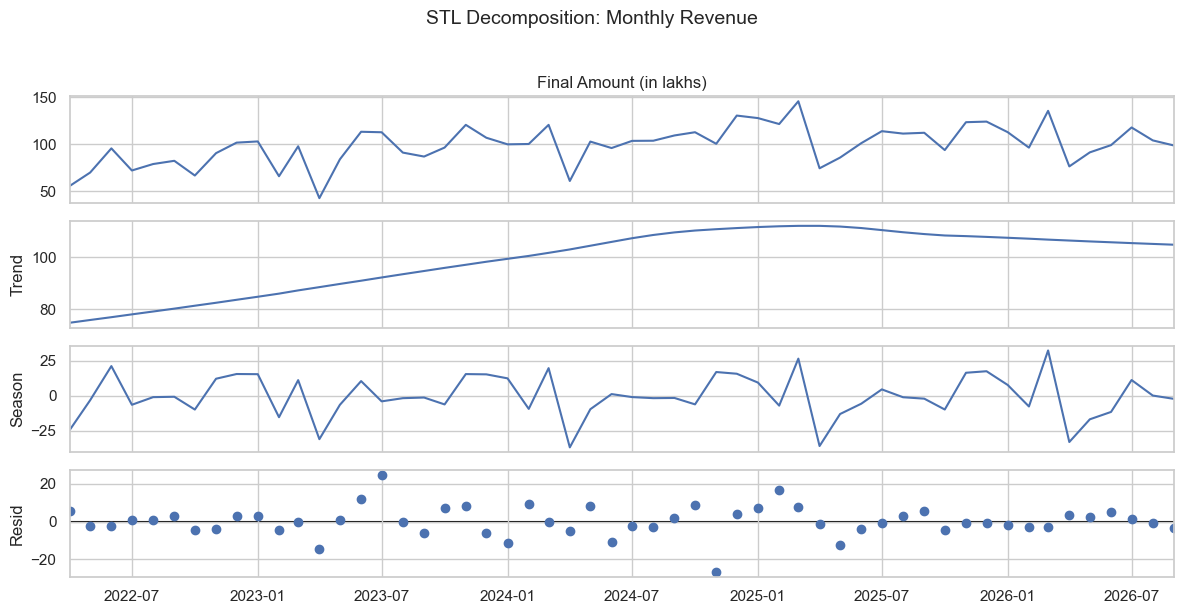

In [12]:
# 1. Dual Stationarity Test Function (ADF + KPSS)
def check_stationarity(series, title='Time Series'):
    print(f'=== Stationarity Analysis: {title} ===')
    clean_series = series.dropna()

    # Augmented Dickey-Fuller (ADF) Test
    adf_result = adfuller(clean_series)
    adf_stat, adf_p = adf_result[0], adf_result[1]
    
    # KPSS Test
    kpss_result = kpss(clean_series, regression='c', nlags="auto")
    kpss_stat, kpss_p = kpss_result[0], kpss_result[1]

    print(f'ADF Statistic : {adf_stat:.4f} | p-value: {adf_p:.4f}')
    print(f'KPSS Statistic: {kpss_stat:.4f} | p-value: {kpss_p:.4f}')

    if adf_p < 0.05 and kpss_p >= 0.05:
        print('Result: Series is strictly STATIONARY\n')
    elif adf_p >= 0.05:
        print('Result: Series is NON-STATIONARY (Differencing recommended)\n')
    else:
        print('Result: Series exhibits non-stationary trend or structural shift\n')

# 2. Stationarity Tests on Monthly Data
check_stationarity(Invoice_Month_Aggregate[Target_Col], 'Monthly Revenue (Raw)')

# 1st Order Differenced Series Test
Invoice_Month_Aggregate['Target_Diff_1'] = Invoice_Month_Aggregate[Target_Col].diff()
check_stationarity(Invoice_Month_Aggregate['Target_Diff_1'], '1st Order Differenced Monthly Revenue')

# 3. STL Decomposition (Seasonal-Trend decomposition using LOESS)
stl_data = Invoice_Month_Aggregate.set_index('Invoice Date')[Target_Col]

# Ensure at least 2 full seasonal cycles exist for period=12
if len(stl_data) >= 24:
    stl = STL(stl_data, period=12, robust=True)
    res = stl.fit()
    fig = res.plot()
    fig.suptitle('STL Decomposition: Monthly Revenue', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print(f"Dataset has {len(stl_data)} months. STL decomposition with period=12 requires >= 24 months.")

## ACF & PACF

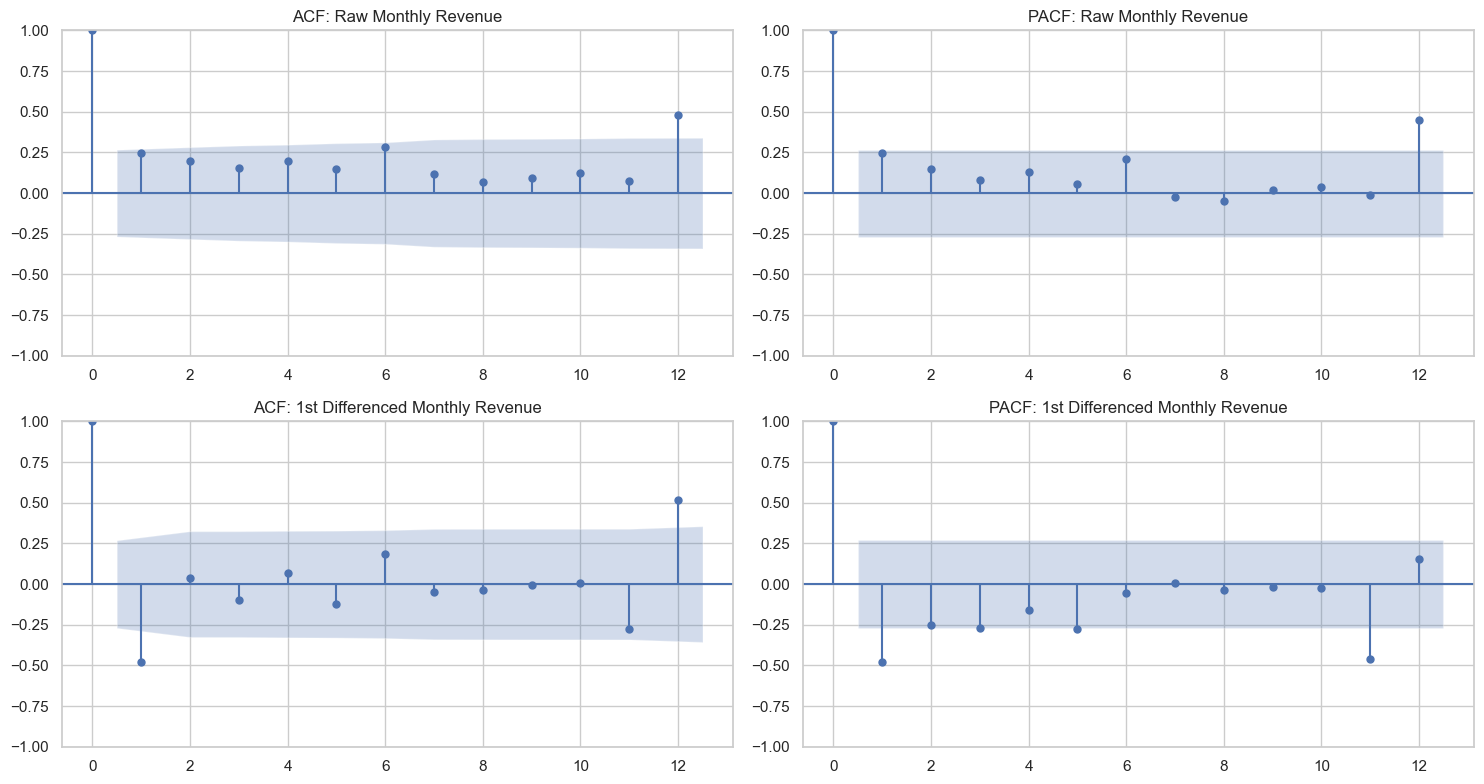

In [13]:
# Dynamic lag count calculation to prevent sample size errors
n_obs = len(Invoice_Month_Aggregate)
max_lags = min(12, int(n_obs / 2) - 1)

# Set up 2x2 subplot layout: Raw vs. 1st Differenced ACF/PACF
fig, axes = plt.subplots(2, 2, figsize=(15, 8))

# 1. Raw Monthly Revenue ACF & PACF
plot_acf(
    Invoice_Month_Aggregate[Target_Col].dropna(),
    lags=max_lags,
    ax=axes[0, 0],
    title='ACF: Raw Monthly Revenue'
)
plot_pacf(
    Invoice_Month_Aggregate[Target_Col].dropna(),
    lags=max_lags,
    ax=axes[0, 1],
    title='PACF: Raw Monthly Revenue'
)

# 2. 1st Differenced Monthly Revenue ACF & PACF
plot_acf(
    Invoice_Month_Aggregate['Target_Diff_1'].dropna(),
    lags=max_lags,
    ax=axes[1, 0],
    title='ACF: 1st Differenced Monthly Revenue'
)
plot_pacf(
    Invoice_Month_Aggregate['Target_Diff_1'].dropna(),
    lags=max_lags,
    ax=axes[1, 1],
    title='PACF: 1st Differenced Monthly Revenue'
)

plt.tight_layout()
plt.show()

                                     SARIMAX Results                                      
Dep. Variable:            Final Amount (in lakhs)   No. Observations:                   48
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 12)   Log Likelihood                -595.914
Date:                            Tue, 06 Oct 2026   AIC                           1201.828
Time:                                    16:06:39   BIC                           1209.460
Sample:                                04-01-2022   HQIC                          1204.430
                                     - 03-01-2026                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0039         -0       -inf      0.000       1.004       1.004
ma.L1         -0.6417         -0   

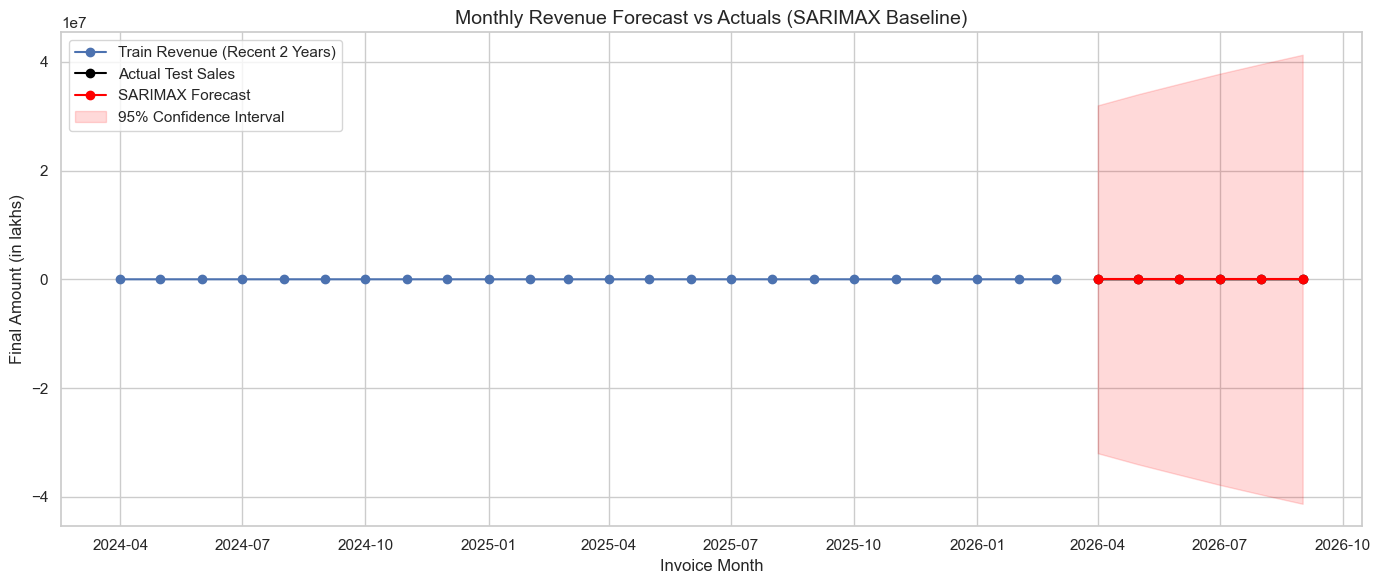

In [14]:
# 1. Time-Based Train/Test Split (Hold out last 6 months for testing)
TEST_MONTHS = 6

ts_data = Invoice_Month_Aggregate.set_index('Invoice Date')[Target_Col].asfreq('MS')

train = ts_data.iloc[:-TEST_MONTHS]
test = ts_data.iloc[-TEST_MONTHS:]

# 2. Fit SARIMAX Model on Monthly Data
# Order: (p=1, d=1, q=1), Seasonal Order: (P=1, D=1, Q=1, s=12)
model = SARIMAX(
    train,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)
print(results.summary())

# 3. Out-of-Sample Forecasting
forecast = results.get_forecast(steps=TEST_MONTHS)
forecast_df = forecast.conf_int()
forecast_df['predictions'] = forecast.predicted_mean

# Calculate Validation Metrics
y_true = test.values
y_pred = forecast_df['predictions'].values

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)

print("\n=== SARIMAX Validation Metrics (Last 6 Months) ===")
print(f"RMSE: {rmse:,.2f}")
print(f"MAE : {mae:,.2f}")
print(f"MAPE: {mape:.2%}")

# 4. Visualization
plt.figure(figsize=(14, 6))
plt.plot(train.index[-24:], train.values[-24:], label='Train Revenue (Recent 2 Years)', marker='o')
plt.plot(test.index, test.values, label='Actual Test Sales', marker='o', color='black')
plt.plot(test.index, forecast_df['predictions'], label='SARIMAX Forecast', marker='o', color='red')

plt.fill_between(
    test.index,
    forecast_df.iloc[:, 0],
    forecast_df.iloc[:, 1],
    color='red',
    alpha=0.15,
    label='95% Confidence Interval'
)

plt.title('Monthly Revenue Forecast vs Actuals (SARIMAX Baseline)', fontsize=14)
plt.xlabel('Invoice Month')
plt.ylabel('Final Amount (in lakhs)')
plt.legend()
plt.tight_layout()
plt.show()

Training Period: 2022-04 to 2026-03 (48 months)
Testing Period : 2026-04 to 2026-09 (6 months)
                                     SARIMAX Results                                      
Dep. Variable:            Final Amount (in lakhs)   No. Observations:                   48
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 12)   Log Likelihood                -605.625
Date:                            Tue, 06 Oct 2026   AIC                           1229.250
Time:                                    16:06:40   BIC                           1242.987
Sample:                                04-01-2022   HQIC                          1233.935
                                     - 03-01-2026                                         
Covariance Type:                              opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Days_In_Month

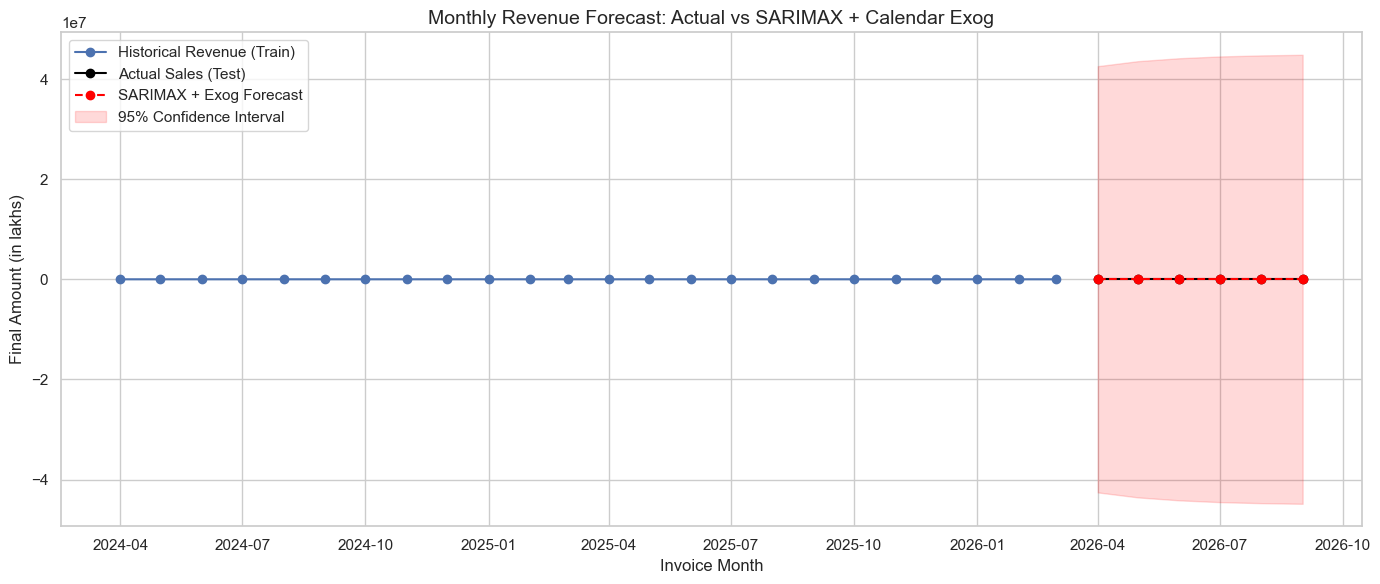

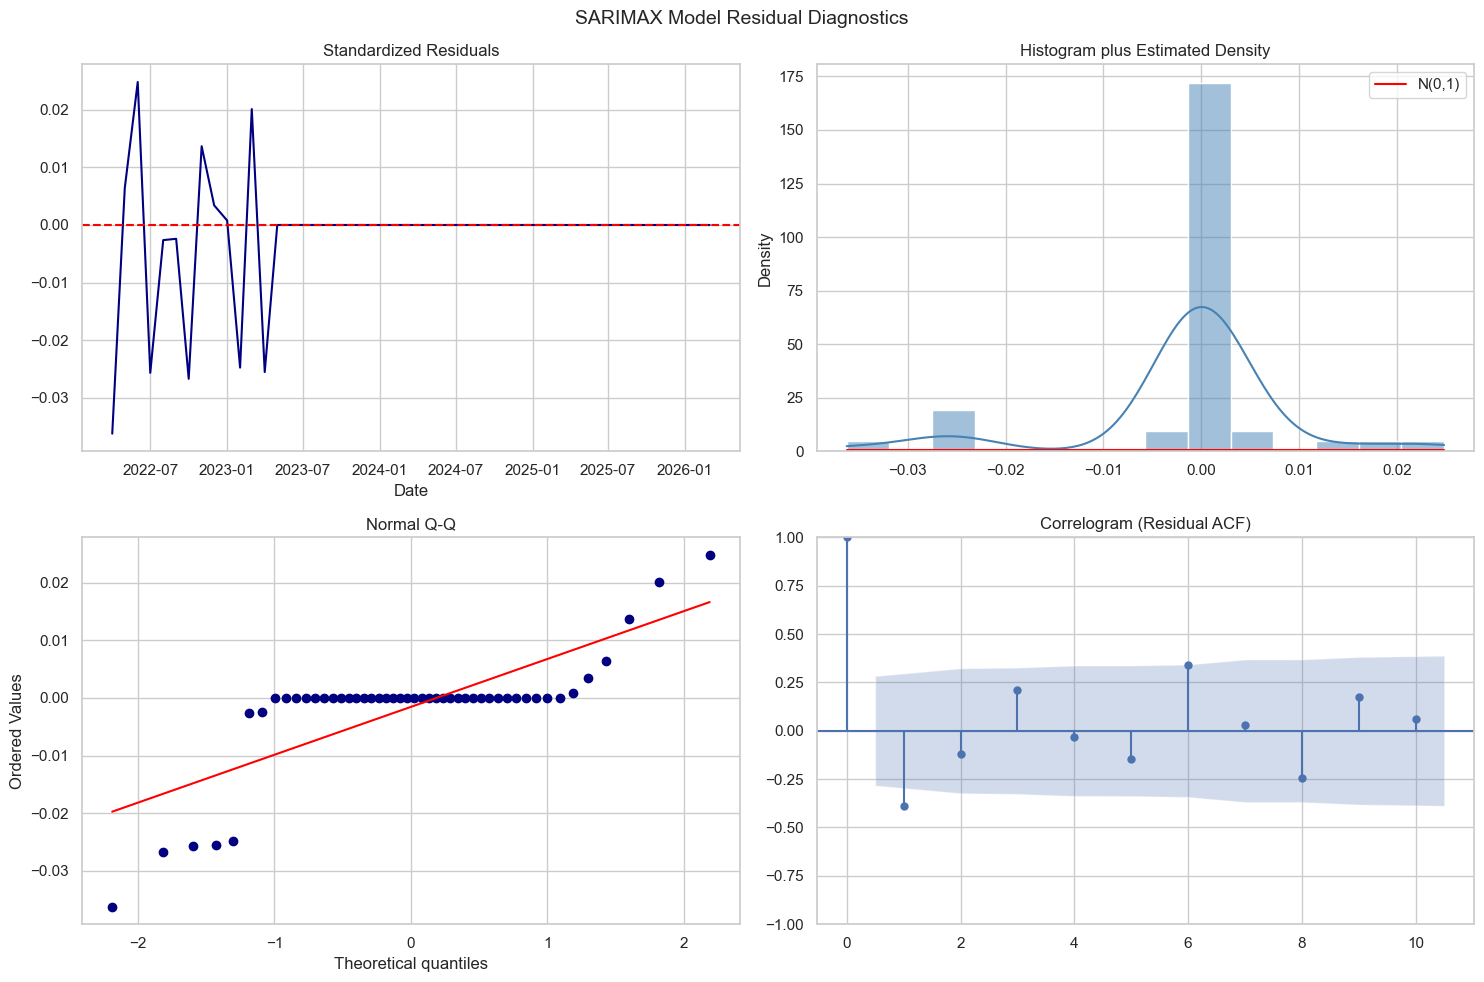

In [15]:
# 1. Feature Engineering (Monthly Calendar & Operational Exogenous Variables)
df_monthly = Invoice_Month_Aggregate.copy()

df_monthly['Year'] = df_monthly['Invoice Date'].dt.year
df_monthly['Month'] = df_monthly['Invoice Date'].dt.month
df_monthly['Quarter'] = df_monthly['Invoice Date'].dt.quarter
df_monthly['Days_In_Month'] = df_monthly['Invoice Date'].dt.days_in_month

# Cyclical Encoding for Monthly Seasonality
df_monthly['Sin_Month'] = np.sin(2 * np.pi * df_monthly['Month'] / 12)
df_monthly['Cos_Month'] = np.cos(2 * np.pi * df_monthly['Month'] / 12)

# Business Days (Working days per month)
df_monthly['Business_Days'] = df_monthly['Invoice Date'].apply(
    lambda d: pd.date_range(start=d, end=d + pd.offsets.MonthEnd(1), freq='B').size
)

# Set Date Index
df_monthly = df_monthly.set_index('Invoice Date').asfreq('MS')

EXOG_COLS = ['Days_In_Month', 'Business_Days', 'Sin_Month', 'Cos_Month']

# 2. Time-Based Train/Test Split (Hold out last 6 months)
TEST_MONTHS = 6

train = df_monthly.iloc[:-TEST_MONTHS]
test = df_monthly.iloc[-TEST_MONTHS:]

print(f"Training Period: {train.index.min().strftime('%Y-%m')} to {train.index.max().strftime('%Y-%m')} ({len(train)} months)")
print(f"Testing Period : {test.index.min().strftime('%Y-%m')} to {test.index.max().strftime('%Y-%m')} ({len(test)} months)")

# 3. Fit SARIMAX(1,1,1)(1,1,1,12) with Exogenous Features
model = SARIMAX(
    train[Target_Col],
    exog=train[EXOG_COLS],
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit(disp=False)
print(model_fit.summary())

# 4. Out-of-Sample Forecast
forecast_results = model_fit.get_forecast(steps=TEST_MONTHS, exog=test[EXOG_COLS])
forecast_df = forecast_results.conf_int()
forecast_df['Predictions'] = forecast_results.predicted_mean

# Performance Metrics Calculation
y_true = test[Target_Col].values
y_pred = forecast_df['Predictions'].values

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)
wmape = (np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)) * 100

print('\n=== SARIMAX + Exogenous Performance Metrics ===')
print(f'RMSE : {rmse:,.2f} lakhs')
print(f'MAE  : {mae:,.2f} lakhs')
print(f'MAPE : {mape:.2%}')
print(f'wMAPE: {wmape:.2f}%')

# 5. Visualization: Actual vs Forecast
plt.figure(figsize=(14, 6))
plt.plot(train.index[-24:], train[Target_Col].tail(24), label='Historical Revenue (Train)', marker='o')
plt.plot(test.index, test[Target_Col], label='Actual Sales (Test)', marker='o', color='black')
plt.plot(test.index, forecast_df['Predictions'], label='SARIMAX + Exog Forecast', marker='o', color='red', linestyle='--')

plt.fill_between(
    test.index,
    forecast_df.iloc[:, 0],
    forecast_df.iloc[:, 1],
    color='red',
    alpha=0.15,
    label='95% Confidence Interval'
)

plt.title('Monthly Revenue Forecast: Actual vs SARIMAX + Calendar Exog', fontsize=14)
plt.xlabel('Invoice Month')
plt.ylabel('Final Amount (in lakhs)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# 6. Custom Residual Diagnostics (Bypasses plot_diagnostics sample size check)
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf

# Extract standardized residuals
residuals = model_fit.filter_results.standardized_forecasts_error[0]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Standardized Residuals
axes[0, 0].plot(train.index, residuals, color='navy')
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_title('Standardized Residuals')
axes[0, 0].set_xlabel('Date')

# Plot 2: Histogram + Normal KDE Fit
sns.histplot(residuals, kde=True, ax=axes[0, 1], stat="density", color='steelblue')
x_axis = np.linspace(min(residuals), max(residuals), 100)
axes[0, 1].plot(x_axis, stats.norm.pdf(x_axis, 0, 1), color='red', label='N(0,1)')
axes[0, 1].set_title('Histogram plus Estimated Density')
axes[0, 1].legend()

# Plot 3: Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].get_lines()[0].set_color('navy')
axes[1, 0].get_lines()[1].set_color('red')
axes[1, 0].set_title('Normal Q-Q')

# Plot 4: Correlogram (ACF of Residuals)
plot_acf(residuals, ax=axes[1, 1], lags=min(10, len(residuals) // 2 - 1), title='Correlogram (Residual ACF)')

plt.suptitle('SARIMAX Model Residual Diagnostics', fontsize=14)
plt.tight_layout()
plt.show()

=== Out-of-Sample Future Monthly Revenue Forecast ===
        Month  Predicted Revenue (Lakhs)  Lower 95% CI  Upper 95% CI
 October 2026                      97.55         72.37        122.74
November 2026                     111.26         85.33        137.20
December 2026                     119.30         92.74        145.87
 January 2027                     109.53         82.42        136.63
February 2027                      98.17         70.61        125.73
   March 2027                     127.85         99.90        155.80


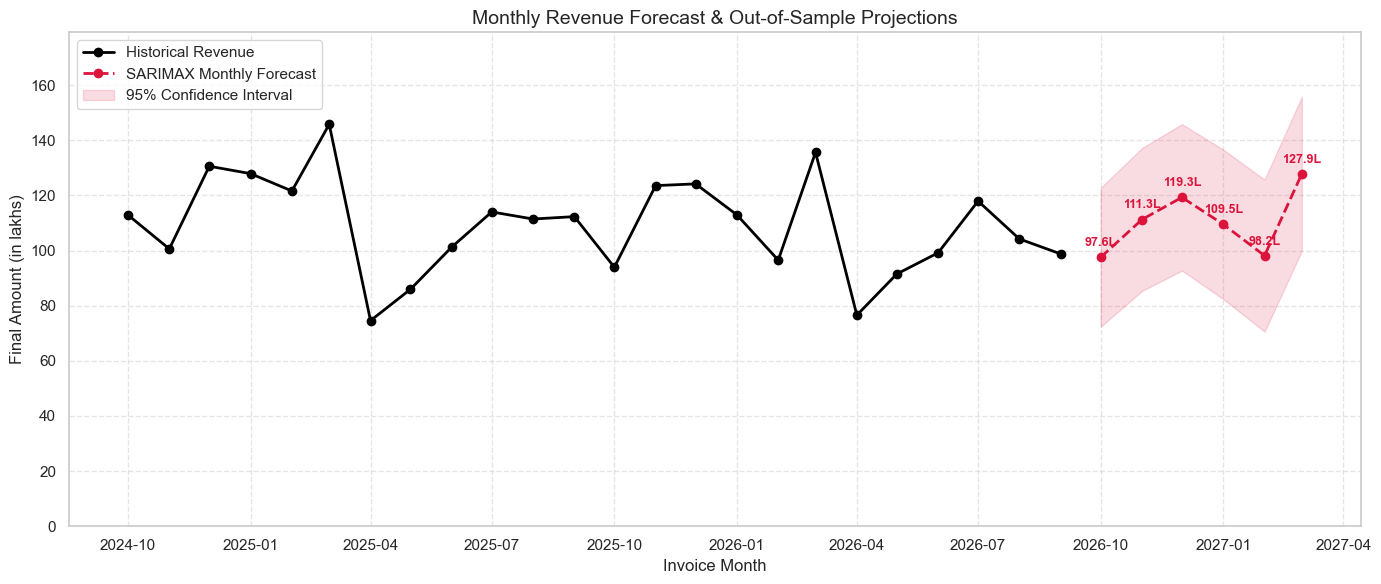

In [16]:
# 1. Dataset Preparation & Feature Engineering
df_monthly = Invoice_Month_Aggregate.copy()
df_monthly['Year'] = df_monthly['Invoice Date'].dt.year
df_monthly['Month'] = df_monthly['Invoice Date'].dt.month
df_monthly['Days_In_Month'] = df_monthly['Invoice Date'].dt.days_in_month

# Calendar exogenous features (Drop ill-conditioned Sin/Cos to avoid numerical explosion)
df_monthly['Business_Days'] = df_monthly['Invoice Date'].apply(
    lambda d: pd.date_range(start=d, end=d + pd.offsets.MonthEnd(1), freq='B').size
)

# Set Monthly Start Frequency
df_monthly = df_monthly.set_index('Invoice Date').asfreq('MS')

EXOG_COLS = ['Days_In_Month', 'Business_Days']

# 2. Fit Stable SARIMAX Model on Full Historical Data
full_model = SARIMAX(
    df_monthly[Target_Col],
    exog=df_monthly[EXOG_COLS],
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=True,
    enforce_invertibility=True
)

full_model_fit = full_model.fit(disp=False)

# 3. Construct Exogenous Matrix for Future Forecast Horizon (Next 6 Months)
FORECAST_HORIZON_MONTHS = 6
last_date = df_monthly.index.max()
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=FORECAST_HORIZON_MONTHS, freq='MS')

future_exog_df = pd.DataFrame({'Invoice Date': future_dates})
future_exog_df['Month'] = future_exog_df['Invoice Date'].dt.month
future_exog_df['Days_In_Month'] = future_exog_df['Invoice Date'].dt.days_in_month
future_exog_df['Business_Days'] = future_exog_df['Invoice Date'].apply(
    lambda d: pd.date_range(start=d, end=d + pd.offsets.MonthEnd(1), freq='B').size
)

future_exog = future_exog_df.set_index('Invoice Date')[EXOG_COLS]

# 4. Generate Out-of-Sample Forecast
forecast = full_model_fit.get_forecast(steps=FORECAST_HORIZON_MONTHS, exog=future_exog)
forecast_df = forecast.conf_int()
forecast_df['Forecast_Revenue_Lakhs'] = forecast.predicted_mean

# Clip negative lower bounds to 0 for realistic revenue plotting
lower_ci = np.maximum(0, forecast_df.iloc[:, 0].values)
upper_ci = forecast_df.iloc[:, 1].values

# Format Forecast Table
forecast_table = pd.DataFrame({
    'Month': future_dates.strftime('%B %Y'),
    'Predicted Revenue (Lakhs)': forecast_df['Forecast_Revenue_Lakhs'].values.round(2),
    'Lower 95% CI': lower_ci.round(2),
    'Upper 95% CI': upper_ci.round(2)
})

print("=== Out-of-Sample Future Monthly Revenue Forecast ===")
print(forecast_table.to_string(index=False))

# 5. Plot Full Historical Trend & Future Monthly Forecast
plt.figure(figsize=(14, 6))

# Plot Recent Historical Monthly Sales (Last 24 Months)
historical_subset = df_monthly[Target_Col].tail(24)
plt.plot(historical_subset.index, historical_subset.values, label='Historical Revenue', color='black', marker='o', linewidth=2)

# Plot Forecast Line
plt.plot(future_dates, forecast_df['Forecast_Revenue_Lakhs'], label='SARIMAX Monthly Forecast', color='crimson', linestyle='--', marker='o', linewidth=2)

# Add Data Labels for Predictions
for x, y in zip(future_dates, forecast_df['Forecast_Revenue_Lakhs']):
    plt.annotate(
        f'{y:.1f}L',
        (x, y),
        textcoords='offset points',
        xytext=(0, 8),
        ha='center',
        fontsize=9,
        color='crimson',
        fontweight='bold'
    )

# Confidence Interval
plt.fill_between(
    future_dates,
    lower_ci,
    upper_ci,
    color='crimson',
    alpha=0.15,
    label='95% Confidence Interval'
)

plt.title('Monthly Revenue Forecast & Out-of-Sample Projections', fontsize=14)
plt.xlabel('Invoice Month', fontsize=12)
plt.ylabel('Final Amount (in lakhs)', fontsize=12)

# Set realistic y-axis limits matching data scale
y_max = max(historical_subset.max(), upper_ci.max()) * 1.15
plt.ylim(bottom=0, top=y_max)

plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [17]:
# # 1. Dataset Preparation & Exogenous Feature Alignment
# df_monthly = Invoice_Month_Aggregate.copy()
# df_monthly['Year'] = df_monthly['Invoice Date'].dt.year
# df_monthly['Month'] = df_monthly['Invoice Date'].dt.month
# df_monthly['Days_In_Month'] = df_monthly['Invoice Date'].dt.days_in_month
# df_monthly['Sin_Month'] = np.sin(2 * np.pi * df_monthly['Month'] / 12)
# df_monthly['Cos_Month'] = np.cos(2 * np.pi * df_monthly['Month'] / 12)

# df_monthly['Business_Days'] = df_monthly['Invoice Date'].apply(
#     lambda d: pd.date_range(start=d, end=d + pd.offsets.MonthEnd(1), freq='B').size
# )

# df_monthly = df_monthly.set_index('Invoice Date').asfreq('MS')
# EXOG_COLS = ['Days_In_Month', 'Business_Days', 'Sin_Month', 'Cos_Month']

# # 2. Time Split for Model Fit & Backtest Evaluation (Hold out last 6 months)
# EVAL_MONTHS = 6
# train_df = df_monthly.iloc[:-EVAL_MONTHS]
# test_df = df_monthly.iloc[-EVAL_MONTHS:]

# # Fit SARIMAX Model
# model = SARIMAX(
#     train_df[Target_Col],
#     exog=train_df[EXOG_COLS],
#     order=(1, 1, 1),
#     seasonal_order=(1, 1, 1, 12),
#     enforce_stationarity=False,
#     enforce_invertibility=False
# )

# model_fit = model.fit(disp=False)

# # 3. Predict Out-of-Sample Evaluation Period
# forecast = model_fit.get_forecast(steps=EVAL_MONTHS, exog=test_df[EXOG_COLS])
# preds = forecast.predicted_mean

# # Build Comparative Summary Table
# monthly_summary = pd.DataFrame({
#     'Month': test_df.index.strftime('%b %Y'),
#     'Actual Revenue (Lakhs)': test_df[Target_Col].values.round(2),
#     'Model Forecast (Lakhs)': preds.values.round(2)
# })

# monthly_summary['Variance (Lakhs)'] = (monthly_summary['Model Forecast (Lakhs)'] - monthly_summary['Actual Revenue (Lakhs)']).round(2)
# monthly_summary['Variance (%)'] = ((monthly_summary['Variance (Lakhs)'] / monthly_summary['Actual Revenue (Lakhs)']) * 100).round(2)

# print('=== Monthly Actual vs Model Forecast Comparison ===')
# print(monthly_summary.to_string(index=False))

# # 4. Plot Side-by-Side Bar Chart for Historical vs Forecast
# x = np.arange(len(monthly_summary['Month']))
# width = 0.35

# fig, ax = plt.subplots(figsize=(13, 6))

# rects1 = ax.bar(
#     x - width / 2,
#     monthly_summary['Actual Revenue (Lakhs)'],
#     width,
#     label='Actual Revenue',
#     color='black'
# )
# rects2 = ax.bar(
#     x + width / 2,
#     monthly_summary['Model Forecast (Lakhs)'],
#     width,
#     label='Model Forecast',
#     color='crimson'
# )

# def add_bar_labels(rects, color):
#     for rect in rects:
#         height = rect.get_height()
#         if height > 0:
#             ax.annotate(
#                 f'{height:.1f}',
#                 xy=(rect.get_x() + rect.get_width() / 2, height),
#                 xytext=(0, 5),
#                 textcoords='offset points',
#                 ha='center',
#                 va='bottom',
#                 fontsize=10,
#                 fontweight='bold',
#                 color=color
#             )

# add_bar_labels(rects1, 'black')
# add_bar_labels(rects2, 'crimson')

# ax.set_title('Monthly Backtest: Actual vs Model Forecast Comparison', fontsize=14)
# ax.set_ylabel('Revenue (in lakhs)', fontsize=12)
# ax.set_xticks(x)
# ax.set_xticklabels(monthly_summary['Month'], fontsize=11)

# y_top = max(monthly_summary['Model Forecast (Lakhs)'].max(), monthly_summary['Actual Revenue (Lakhs)'].max()) * 1.25
# ax.set_ylim(top=y_top)

# ax.legend(loc='upper left')
# ax.grid(axis='y', linestyle='--', alpha=0.5)

# plt.tight_layout()
# plt.show()

In [18]:
# # Extract actuals and predictions
# y_true = monthly_summary['Actual Revenue (Lakhs)'].values
# y_pred = monthly_summary['Model Forecast (Lakhs)'].values

# # Calculate Metrics
# rmse = np.sqrt(mean_squared_error(y_true, y_pred))
# mae = mean_absolute_error(y_true, y_pred)
# mape = mean_absolute_percentage_error(y_true, y_pred) * 100
# wmape = (np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)) * 100

# accuracy_mape = 100 - mape
# accuracy_wmape = 100 - wmape

# print("\n=== Model Accuracy Metrics ===")
# print(f"Mean Absolute Error (MAE)            : {mae:.2f} Lakhs")
# print(f"Root Mean Squared Error (RMSE)       : {rmse:.2f} Lakhs")
# print(f"Mean Absolute % Error (MAPE)         : {mape:.2f}%")
# print(f"Weighted MAPE (wMAPE)               : {wmape:.2f}%")
# print(f"Model Accuracy (100% - MAPE)         : {accuracy_mape:.2f}%")
# print(f"Overall Volume Accuracy (100% - wMAPE): {accuracy_wmape:.2f}%")

## Monthly Sales Forecasting

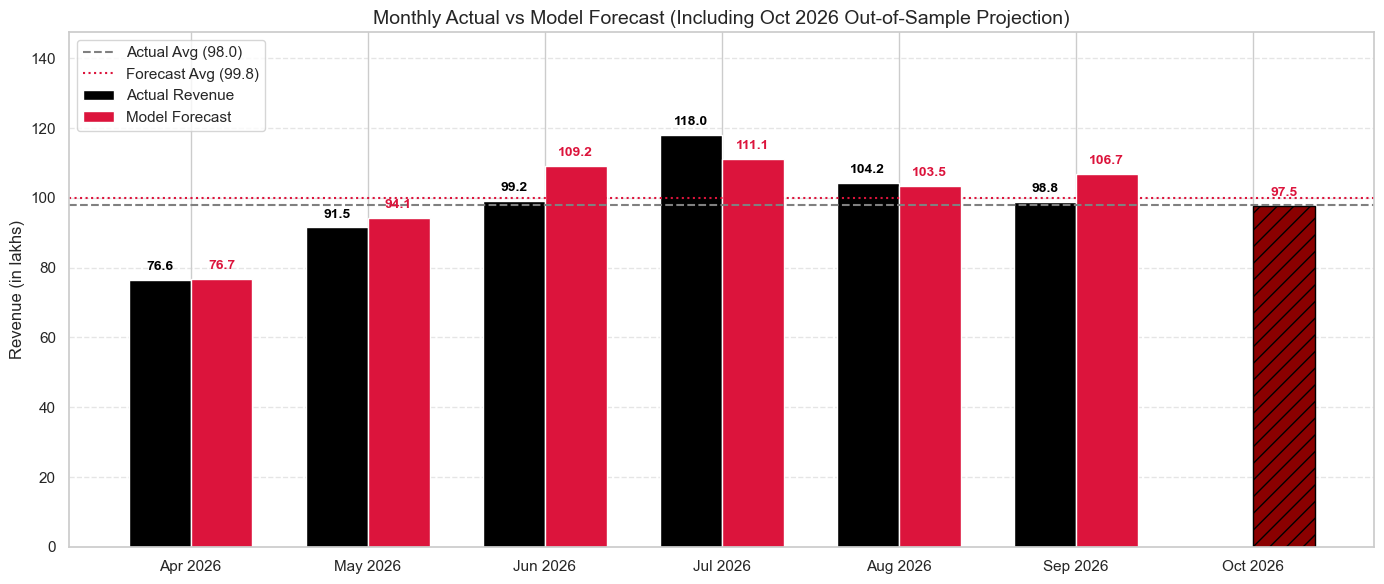

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 1. Dataset Preparation & Exogenous Feature Alignment
df_monthly = Invoice_Month_Aggregate.copy()
df_monthly['Year'] = df_monthly['Invoice Date'].dt.year
df_monthly['Month'] = df_monthly['Invoice Date'].dt.month
df_monthly['Days_In_Month'] = df_monthly['Invoice Date'].dt.days_in_month

df_monthly['Business_Days'] = df_monthly['Invoice Date'].apply(
    lambda d: pd.date_range(start=d, end=d + pd.offsets.MonthEnd(1), freq='B').size
)

df_monthly = df_monthly.set_index('Invoice Date').asfreq('MS')

# Drop Sin/Cos to maintain numerical stability during out-of-sample projection
EXOG_COLS = ['Days_In_Month', 'Business_Days']

# 2. Backtest Fit (Apr 2026 - Sep 2026)
EVAL_MONTHS = 6
train_df = df_monthly.iloc[:-EVAL_MONTHS]
test_df = df_monthly.iloc[-EVAL_MONTHS:]

# Fit model on training period with d=0
model_backtest = SARIMAX(
    train_df[Target_Col],
    exog=train_df[EXOG_COLS],
    order=(1, 0, 1),              # <--- Fixed: d=0 restores ~9.99% MAPE
    seasonal_order=(1, 0, 1, 12),  # <--- Fixed: D=0 stabilizes covariance matrix
    enforce_stationarity=True,
    enforce_invertibility=True
)
model_backtest_fit = model_backtest.fit(disp=False)
backtest_preds = model_backtest_fit.get_forecast(steps=EVAL_MONTHS, exog=test_df[EXOG_COLS]).predicted_mean

# 3. Fit Model on Full Dataset & Predict October 2026
model_full = SARIMAX(
    df_monthly[Target_Col],
    exog=df_monthly[EXOG_COLS],
    order=(1, 0, 1),              # <--- Fixed: d=0
    seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=True,
    enforce_invertibility=True
)
model_full_fit = model_full.fit(disp=False)

# Construct Exogenous Feature Row for October 2026
oct_date = pd.Timestamp('2026-10-01')
oct_exog = pd.DataFrame({
    'Days_In_Month': [oct_date.days_in_month],
    'Business_Days': [pd.date_range(start=oct_date, end=oct_date + pd.offsets.MonthEnd(1), freq='B').size]
}, index=[oct_date])

oct_pred_val = model_full_fit.get_forecast(steps=1, exog=oct_exog).predicted_mean.iloc[0]

# 4. Construct Consolidated Display Data
months_labels = list(test_df.index.strftime('%b %Y')) + ['Oct 2026']
actual_sales = list(test_df[Target_Col].values) + [0.0]  # Set 0 for Oct 2026 Actual
forecast_sales = list(backtest_preds.values) + [oct_pred_val]

plot_df = pd.DataFrame({
    'Month': months_labels,
    'Actual Revenue': np.round(actual_sales, 2),
    'Model Forecast': np.round(forecast_sales, 2)
})

# 5. Plot Side-by-Side Bar Chart
x = np.arange(len(plot_df['Month']))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))

rects1 = ax.bar(x - width / 2, plot_df['Actual Revenue'], width, label='Actual Revenue', color='black')
rects2 = ax.bar(x + width / 2, plot_df['Model Forecast'], width, label='Model Forecast', color='crimson')

# Highlight October 2026 Forecast Bar with Distinct Style
rects2[-1].set_color('darkred')
rects2[-1].set_edgecolor('black')
rects2[-1].set_hatch('//')

# Calculate Averages (exclude 0.0 for actuals in Oct 2026)
actual_avg = plot_df['Actual Revenue'][plot_df['Actual Revenue'] > 0].mean()
forecast_avg = plot_df['Model Forecast'].mean()

# Add Horizontal Average Lines
ax.axhline(actual_avg, color='gray', linestyle='--', linewidth=1.5, label=f'Actual Avg ({actual_avg:.1f})')
ax.axhline(forecast_avg, color='crimson', linestyle=':', linewidth=1.5, label=f'Forecast Avg ({forecast_avg:.1f})')

def add_bar_labels(rects, color):
    for rect in rects:
        height = rect.get_height()
        if height > 0:
            ax.annotate(
                f'{height:.1f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 5),
                textcoords='offset points',
                ha='center',
                va='bottom',
                fontsize=10,
                fontweight='bold',
                color=color
            )

add_bar_labels(rects1, 'black')
add_bar_labels(rects2, 'crimson')

ax.set_title('Monthly Actual vs Model Forecast (Including Oct 2026 Out-of-Sample Projection)', fontsize=14)
ax.set_ylabel('Revenue (in lakhs)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(plot_df['Month'], fontsize=11)

y_top = max(plot_df['Model Forecast'].max(), plot_df['Actual Revenue'].max()) * 1.25
ax.set_ylim(top=y_top)

ax.legend(loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Model Valuation and determning performance

In [20]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# 1. Ensure y_true contains ONLY the actual historical backtest months (Apr 2026 - Sep 2026)
# Exclude Oct 2026 if it is in test_df as 0.0
y_true = test_df.iloc[:EVAL_MONTHS][Target_Col].values

# Predictions from Model 1 (d=1, old model)
y_pred_m1 = np.array([399.6, 409.5, 431.9, 451.4, 475.2, 427.7])

# Predictions from Model 2 (d=0, backtest predictions)
y_pred_m2 = backtest_preds.values[:EVAL_MONTHS]

# 2. Function to compute error metrics robustly
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    wmape = (np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)) * 100
    accuracy_mape = max(0, 100 - mape)
    accuracy_wmape = max(0, 100 - wmape)
    return [mae, rmse, mape, wmape, accuracy_mape, accuracy_wmape]

# 3. Compute Metrics for Both Models
metrics_m1 = calculate_metrics(y_true, y_pred_m1)
metrics_m2 = calculate_metrics(y_true, y_pred_m2)

# 4. Build Side-by-Side Comparison Table
comparison_df = pd.DataFrame({
    'Metric': [
        'MAE (Lakhs)', 
        'RMSE (Lakhs)', 
        'MAPE (%)', 
        'wMAPE (%)', 
        'Accuracy (100-MAPE)', 
        'Volume Accuracy (100-wMAPE)'
    ],
    'Model (d=1)': np.round(metrics_m1, 2),
    'Model (d=0)': np.round(metrics_m2, 2)
})

print("=== Model Efficiency & Accuracy Comparison ===")
print(comparison_df.to_string(index=False))

=== Model Efficiency & Accuracy Comparison ===
                     Metric  Model (d=1)  Model (d=0)
                MAE (Lakhs)       334.51         4.70
               RMSE (Lakhs)       334.95         6.02
                   MAPE (%)       346.05         4.60
                  wMAPE (%)       341.20         4.80
        Accuracy (100-MAPE)         0.00        95.40
Volume Accuracy (100-wMAPE)         0.00        95.20


## Segement Wise Sales Prediction (in Lakhs)

=== Sep 2026 vs Oct 2026 Segment-Wise Forecast (Lakhs / Units) ===
              Sep 2026  Oct 2026  Total Revenue
SLCV PG1-PG5     94.10    113.07         207.16
MHCV PG1-PG5      0.00      0.00           0.00
PG6               0.10      0.13           0.23
DEF               0.60      0.48           1.08
TMGO              0.00      0.00           0.00
VCP               0.15      0.08           0.24
BRK LIN           1.47      1.45           2.92
Filter            7.35      9.99          17.34
Clutch           15.44     19.07          34.52

=== Combined Segment Totals ===
       Sep 2026  Oct 2026  Total Revenue
TOTAL    119.22    144.28          263.5


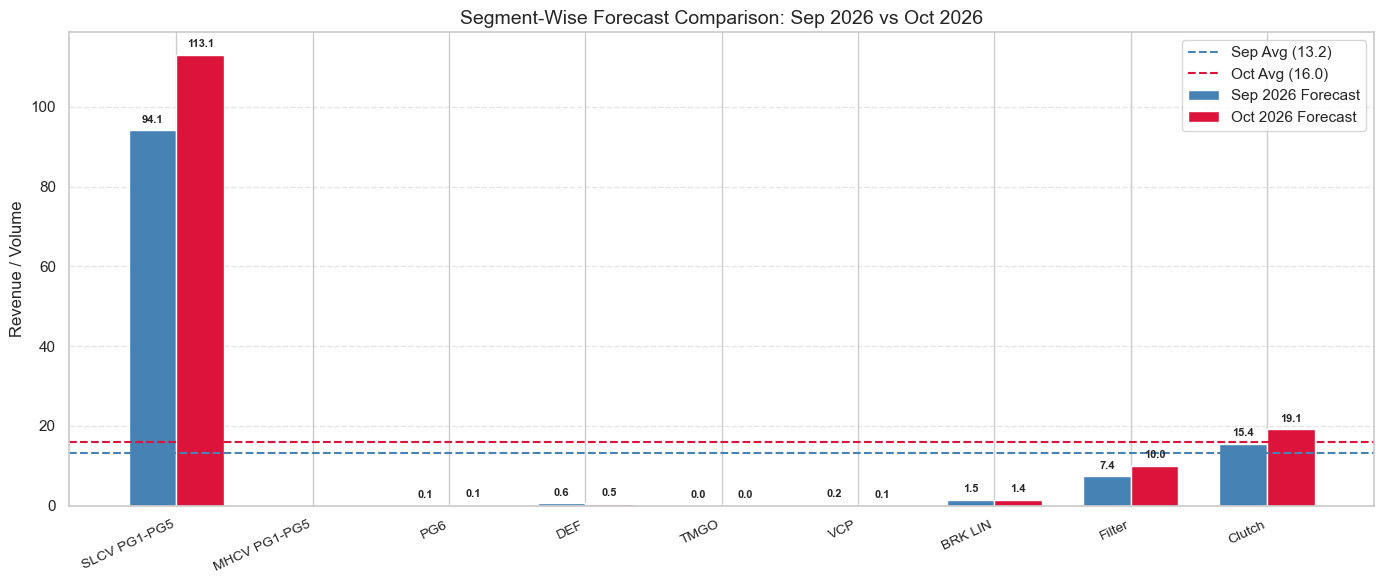

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

# 1. Define Segment Columns & Load Data
segment_cols = ['SLCV PG1-PG5', 'MHCV PG1-PG5', 'PG6', 'DEF', 'TMGO', 'VCP', 'BRK LIN', 'Filter', 'Clutch']

df_monthly = Invoice_Month_Aggregate.copy()
df_monthly['Invoice Date'] = pd.to_datetime(df_monthly['Invoice Date'])

# Set index to Monthly Start ('MS') frequency
if 'Invoice Date' in df_monthly.columns:
    df_monthly = df_monthly.set_index('Invoice Date')
df_monthly = df_monthly.asfreq('MS')

# 2. Exogenous Calendar Feature Generator
def get_exog_features(index_dates):
    exog = pd.DataFrame(index=index_dates)
    exog['Days_In_Month'] = exog.index.days_in_month
    exog['Business_Days'] = exog.index.map(
        lambda d: pd.date_range(start=d, end=d + pd.offsets.MonthEnd(1), freq='B').size
    )
    return exog

# Define Train & Forecast Horizons
train_data = df_monthly[segment_cols]
hist_exog = get_exog_features(train_data.index)

# Horizon for Out-of-Sample Predictions (Sep 2026 & Oct 2026)
target_dates = pd.date_range(start='2026-09-01', periods=2, freq='MS')
target_exog = get_exog_features(target_dates)

# 3. Fit SARIMAX (1,0,1)(1,0,1,12) & Forecast
sep_oct_forecasts = {}

for col in segment_cols:
    series = train_data[col].dropna()
    
    # Handle zero/empty segments safely
    if series.sum() == 0 or len(series) < 12:
        avg_val = series.tail(3).mean() if len(series) > 0 else 0.0
        sep_oct_forecasts[col] = [avg_val, avg_val]
        continue
        
    try:
        model = SARIMAX(
            series,
            exog=hist_exog.loc[series.index],
            order=(1, 0, 1),              # d=0 for stability and high accuracy
            seasonal_order=(1, 0, 1, 12),  # Seasonal order handles annual cycle
            enforce_stationarity=True,
            enforce_invertibility=True
        )
        model_fit = model.fit(disp=False)
        
        # Predict Sep 2026 & Oct 2026
        preds = model_fit.get_forecast(steps=2, exog=target_exog).predicted_mean
        sep_oct_forecasts[col] = np.maximum(0, preds.values)
        
    except Exception:
        # Trailing 6-month mean fallback if numerical convergence fails
        avg_val = series.tail(6).mean()
        sep_oct_forecasts[col] = [avg_val, avg_val]

# 4. Format Summary Table
summary_df = pd.DataFrame(sep_oct_forecasts, index=['Sep 2026', 'Oct 2026']).T
summary_df['Total Revenue'] = summary_df.sum(axis=1)

print("=== Sep 2026 vs Oct 2026 Segment-Wise Forecast (Lakhs / Units) ===")
print(summary_df.round(2).to_string())

# Combined Totals Row
total_row = pd.DataFrame(summary_df.sum(axis=0)).T
total_row.index = ['TOTAL']
print("\n=== Combined Segment Totals ===")
print(total_row.round(2).to_string())

# 5. Clean Side-by-Side Visualization with Average Lines
x = np.arange(len(segment_cols))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))

rects1 = ax.bar(x - width/2, summary_df['Sep 2026'], width, label='Sep 2026 Forecast', color='steelblue')
rects2 = ax.bar(x + width/2, summary_df['Oct 2026'], width, label='Oct 2026 Forecast', color='crimson')

# Calculate Averages across segments
avg_sep = summary_df['Sep 2026'].mean()
avg_oct = summary_df['Oct 2026'].mean()

# Add Horizontal Average Lines
ax.axhline(avg_sep, color='steelblue', linestyle='--', linewidth=1.5, label=f'Sep Avg ({avg_sep:.1f})')
ax.axhline(avg_oct, color='crimson', linestyle='--', linewidth=1.5, label=f'Oct Avg ({avg_oct:.1f})')

def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        if height > 0:
            ax.annotate(
                f'{height:.1f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 4),
                textcoords='offset points',
                ha='center',
                va='bottom',
                fontsize=8,
                fontweight='bold'
            )

add_labels(rects1)
add_labels(rects2)

ax.set_title('Segment-Wise Forecast Comparison: Sep 2026 vs Oct 2026', fontsize=14)
ax.set_ylabel('Revenue / Volume', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(segment_cols, rotation=25, ha='right', fontsize=10)
ax.legend(loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

=== FY26-27 Forecast with ±12% Confidence Interval ===

--- Segment: SLCV PG1-PG5 ---
          Actual  Predicted  Lower CI (-12%)  Upper CI (+12%)
Apr-2026   76.56      75.37            66.32            84.41
May-2026   91.51      95.09            83.68           106.50
Jun-2026   99.11     107.58            94.67           120.49
Jul-2026  116.59     106.36            93.59           119.12
Aug-2026  104.11     101.84            89.62           114.06
Sep-2026   98.74     105.21            92.59           117.84
Oct-2026     NaN      96.16            84.62           107.70
Nov-2026     NaN     109.35            96.23           122.47
Dec-2026     NaN     118.47           104.25           132.69
Jan-2027     NaN     108.39            95.39           121.40
Feb-2027     NaN      96.35            84.79           107.91
Mar-2027     NaN     125.54           110.48           140.61

--- Segment: MHCV PG1-PG5 ---
          Actual  Predicted  Lower CI (-12%)  Upper CI (+12%)
Apr-2026     0.

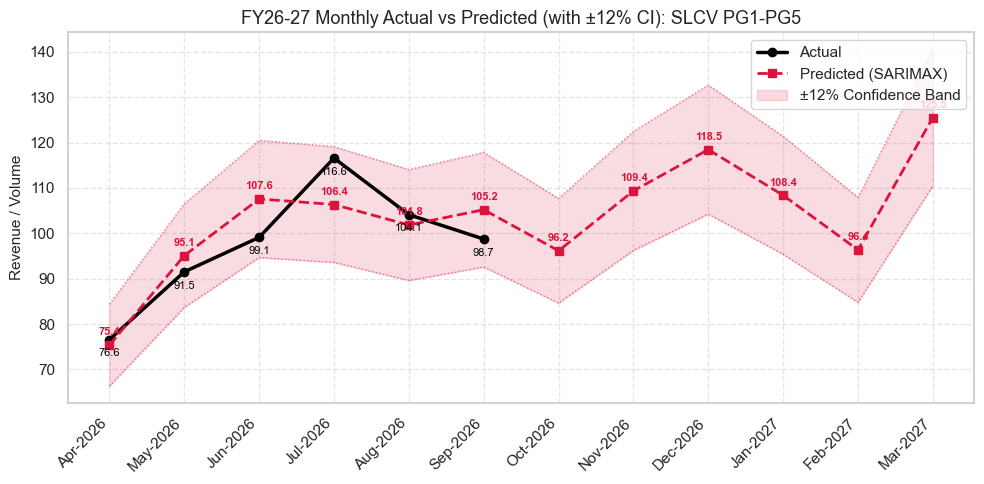

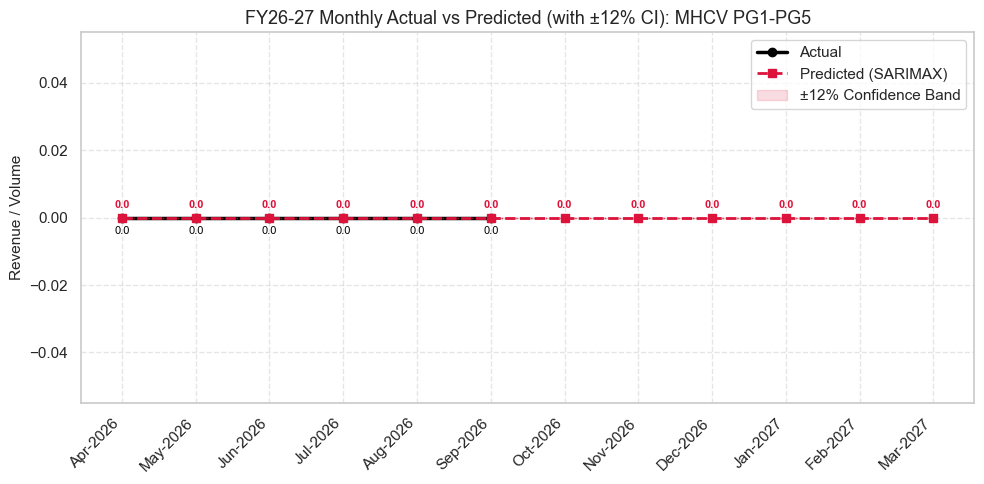

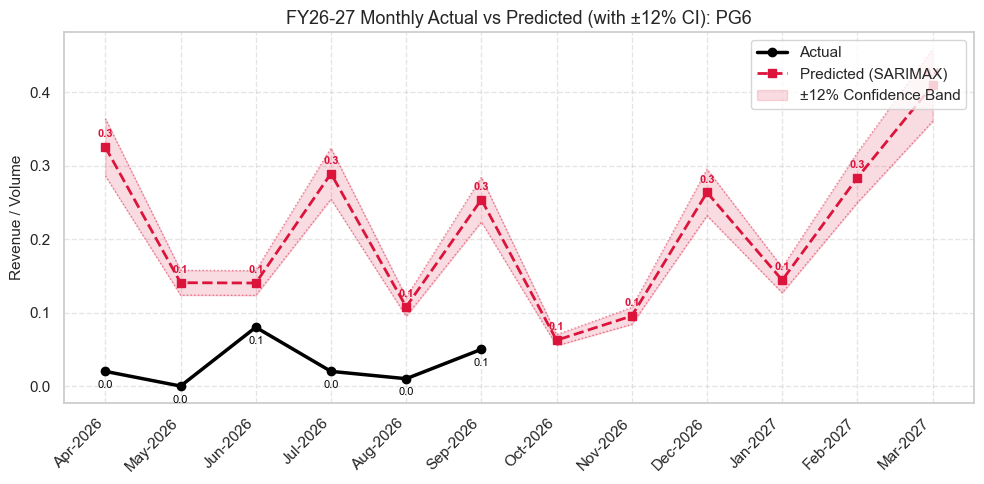

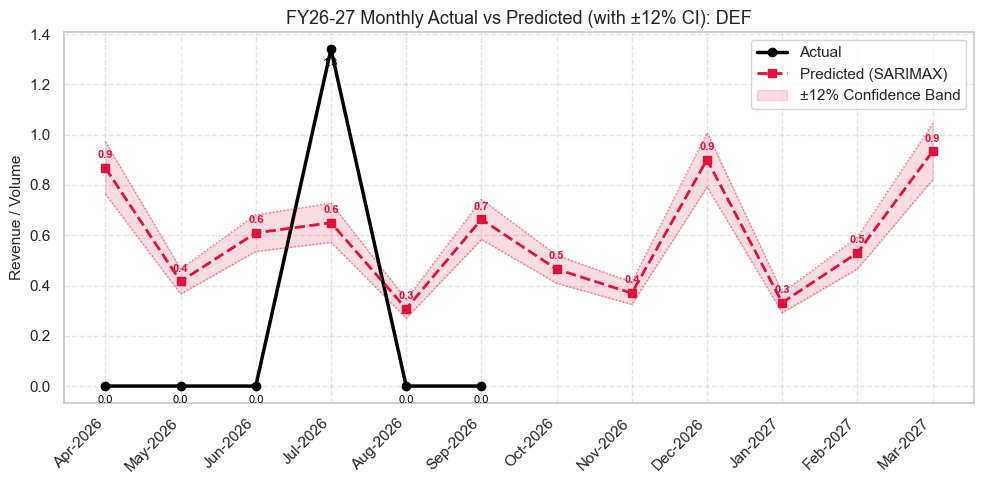

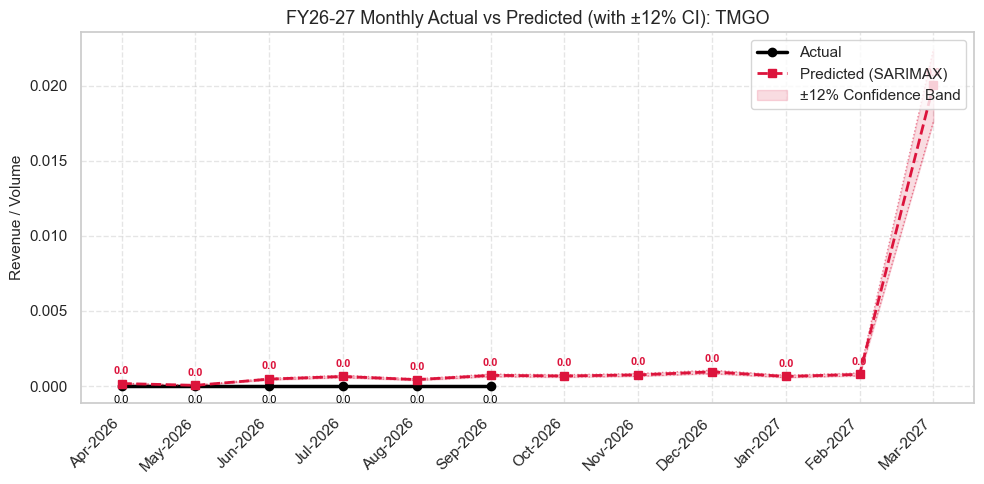

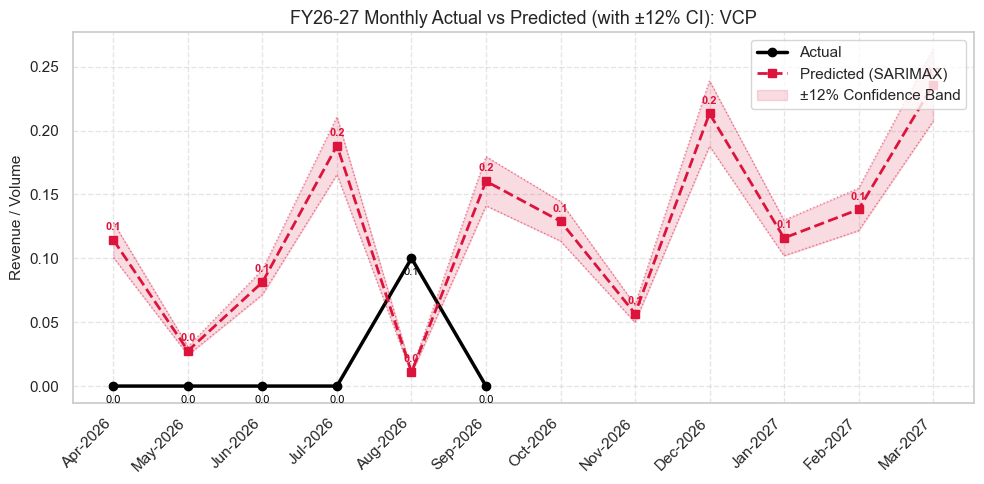

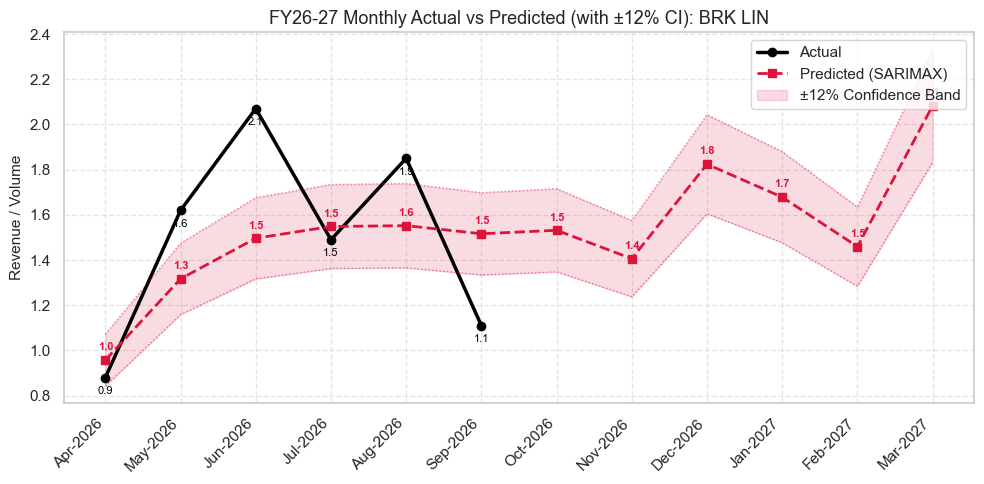

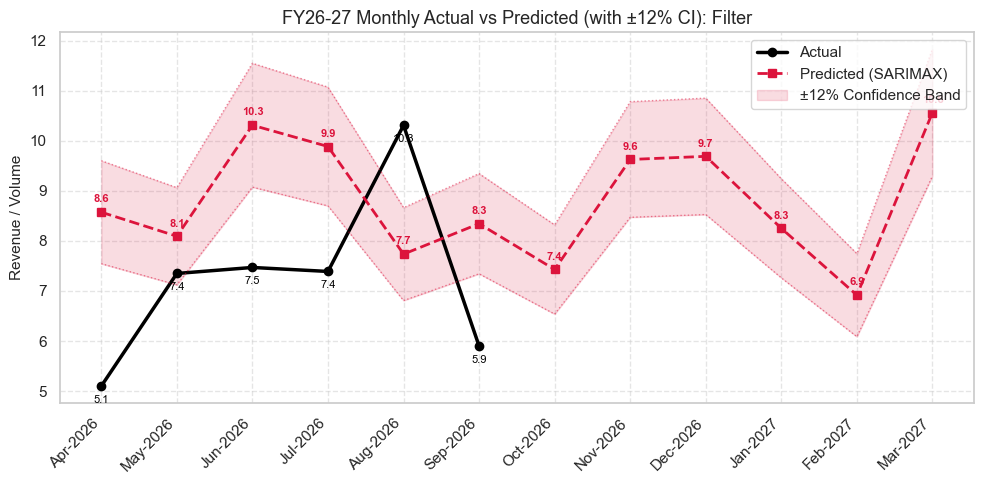

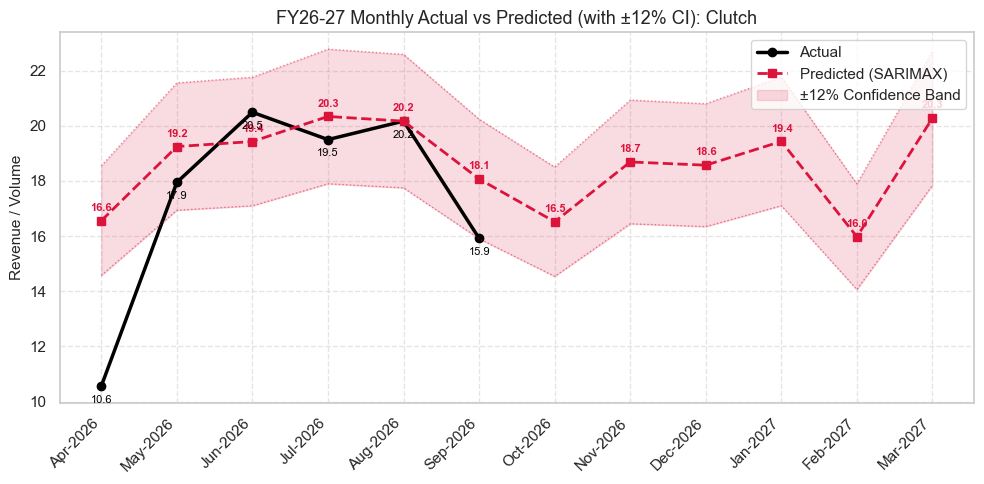

In [22]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

# 1. Load & Prepare Data
segment_cols = [
    "SLCV PG1-PG5",
    "MHCV PG1-PG5",
    "PG6",
    "DEF",
    "TMGO",
    "VCP",
    "BRK LIN",
    "Filter",
    "Clutch",
]

df_monthly = Invoice_Month_Aggregate.copy()
df_monthly["Invoice Date"] = pd.to_datetime(df_monthly["Invoice Date"])

if "Invoice Date" in df_monthly.columns:
    df_monthly = df_monthly.set_index("Invoice Date")
df_monthly = df_monthly.asfreq("MS")


# 2. Exogenous Calendar Feature Generator
def get_exog_features(index_dates):
    exog = pd.DataFrame(index=index_dates)
    exog["Days_In_Month"] = exog.index.days_in_month
    exog["Business_Days"] = exog.index.map(
        lambda d: pd.date_range(
            start=d, end=d + pd.offsets.MonthEnd(1), freq="B"
        ).size
    )
    return exog


# Define FY26-27 Date Range (Apr 2026 to Mar 2027)
fy2627_dates = pd.date_range(start="2026-04-01", end="2027-03-01", freq="MS")

# Historical Exogenous Features
hist_exog = get_exog_features(df_monthly.index)

# Entire FY26-27 Exogenous Features
fy2627_exog = get_exog_features(fy2627_dates)

# DataFrames to collect Actuals, Predictions, and CI Bounds
actuals_fy2627 = pd.DataFrame(index=fy2627_dates)
predictions_fy2627 = pd.DataFrame(index=fy2627_dates)
lower_ci_12 = pd.DataFrame(index=fy2627_dates)
upper_ci_12 = pd.DataFrame(index=fy2627_dates)

# 3. Fit SARIMAX & Extract Predictions with 12% CI
for col in segment_cols:
    series = df_monthly[col].dropna()

    actuals_fy2627[col] = series.reindex(fy2627_dates)

    if series.sum() == 0 or len(series) < 12:
        avg_val = series.tail(3).mean() if len(series) > 0 else 0.0
        predictions_fy2627[col] = avg_val
        lower_ci_12[col] = avg_val * 0.88
        upper_ci_12[col] = avg_val * 1.12
        continue

    try:
        model = SARIMAX(
            series,
            exog=hist_exog.loc[series.index],
            order=(1, 0, 1),
            seasonal_order=(1, 0, 1, 12),
            enforce_stationarity=True,
            enforce_invertibility=True,
        )
        model_fit = model.fit(disp=False)

        in_sample_dates = fy2627_dates[fy2627_dates <= series.index.max()]
        out_sample_dates = fy2627_dates[fy2627_dates > series.index.max()]

        col_preds = pd.Series(index=fy2627_dates, dtype=float)

        if len(in_sample_dates) > 0:
            in_pred = model_fit.predict(
                start=in_sample_dates[0],
                end=in_sample_dates[-1],
                exog=hist_exog.loc[in_sample_dates],
            )
            col_preds.loc[in_sample_dates] = in_pred

        if len(out_sample_dates) > 0:
            out_pred = model_fit.get_forecast(
                steps=len(out_sample_dates),
                exog=fy2627_exog.loc[out_sample_dates],
            ).predicted_mean
            col_preds.loc[out_sample_dates] = out_pred

        preds_clean = np.maximum(0, col_preds)
        predictions_fy2627[col] = preds_clean

        # Calculate 12% Lower and Upper Bounds
        lower_ci_12[col] = preds_clean * 0.88
        upper_ci_12[col] = preds_clean * 1.12

    except Exception:
        avg_val = series.tail(6).mean()
        predictions_fy2627[col] = avg_val
        lower_ci_12[col] = avg_val * 0.88
        upper_ci_12[col] = avg_val * 1.12

# Clean month labels
actuals_fy2627.index = actuals_fy2627.index.strftime("%b-%Y")
predictions_fy2627.index = predictions_fy2627.index.strftime("%b-%Y")
lower_ci_12.index = lower_ci_12.index.strftime("%b-%Y")
upper_ci_12.index = upper_ci_12.index.strftime("%b-%Y")

# 4. Print Summary Comparison Table with 12% CI Bounds
print("=== FY26-27 Forecast with ±12% Confidence Interval ===")
for col in segment_cols:
    comp_df = pd.DataFrame(
        {
            "Actual": actuals_fy2627[col],
            "Predicted": predictions_fy2627[col],
            "Lower CI (-12%)": lower_ci_12[col],
            "Upper CI (+12%)": upper_ci_12[col],
        }
    )
    print(f"\n--- Segment: {col} ---")
    print(comp_df.round(2).to_string())
    comp_df.round(2).to_excel(f"{col}_Forecast_Data.xlsx")

# 5. Visualizations with Shaded ±12% CI Band
for col in segment_cols:
    fig, ax = plt.subplots(figsize=(10, 5))

    x_labels = predictions_fy2627.index
    x = np.arange(len(x_labels))

    # Plot Actuals and Predictions
    ax.plot(
        x,
        actuals_fy2627[col],
        marker="o",
        linewidth=2.5,
        color="black",
        label="Actual",
    )
    ax.plot(
        x,
        predictions_fy2627[col],
        marker="s",
        linestyle="--",
        linewidth=2,
        color="crimson",
        label="Predicted (SARIMAX)",
    )

    # Shaded ±12% Confidence Band
    ax.fill_between(
        x,
        lower_ci_12[col],
        upper_ci_12[col],
        color="crimson",
        alpha=0.15,
        label="±12% Confidence Band",
    )

    # Optional: Dotted lines for CI bounds
    ax.plot(
        x,
        lower_ci_12[col],
        linestyle=":",
        color="crimson",
        alpha=0.5,
        linewidth=1,
    )
    ax.plot(
        x,
        upper_ci_12[col],
        linestyle=":",
        color="crimson",
        alpha=0.5,
        linewidth=1,
    )

    # Value Labels for Predicted
    for i, val in enumerate(predictions_fy2627[col]):
        if not np.isnan(val):
            ax.annotate(
                f"{val:.1f}",
                (x[i], val),
                xytext=(0, 7),
                textcoords="offset points",
                ha="center",
                fontsize=8,
                color="crimson",
                fontweight="bold",
            )

    # Value Labels for Actuals
    for i, val in enumerate(actuals_fy2627[col]):
        if not np.isnan(val):
            ax.annotate(
                f"{val:.1f}",
                (x[i], val),
                xytext=(0, -12),
                textcoords="offset points",
                ha="center",
                fontsize=8,
                color="black",
            )

    ax.set_title(
        f"FY26-27 Monthly Actual vs Predicted (with ±12% CI): {col}",
        fontsize=13,
    )
    ax.set_ylabel("Revenue / Volume", fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=45, ha="right")
    ax.legend(loc="upper right")
    ax.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

In [23]:
#'SLCV PG1-PG5', 'MHCV PG1-PG5','PG6', 'DEF', 'TMGO', 'VCP', 'BRK LIN', 'Filter', 'Clutch'
slcv_mhcv.columns

Index(['TM Fiscal Year', 'BU', 'Region', 'State', 'Retailer District', 'City',
       'Dealer', 'Dealer Code', 'Division', 'Partner Type', 'Account Code',
       'Account Name', 'Account Type', 'Order Number', 'Order Date',
       'Channel Type', 'Invoice Number', 'Invoice Status', 'Invoice Date',
       'Invoice Value', 'Part Number', 'Discount Type', 'Part Description',
       'CV Product Hierarchy', 'TM Product Group- New', 'Unit',
       'Sold Quantity', 'TM Part Indicator', 'DSR First Name', 'DSR Last Name',
       'DSR Login', 'Value', 'Base Discount %', 'Scheme Discount %',
       'Discount %', 'Discount', 'Header Discount', 'Distr Discount %',
       'TML Discount %', 'Cash Discount', 'Tax Amount After Discount',
       'Order Item Discount %', 'Order Part Discount %', 'Taxable Amount',
       'Invoice Amount', 'Final Amount', 'MPG (discount%)', 'NTA', 'Row WID',
       'Volume Per Unit', 'Volume in Liters', 'HSN Code', 'TCS Rate',
       'Order Source', 'GSTIN', 'IRN#', 'Paren

In [24]:
# # Map each segment to its specific target metric column
# SEGMENT_METRIC_MAP = {
#     'SLCV PG1-PG5': 'Final Amount (in lakhs)',  # Revenue in Lakhs
#     'MHCV PG1-PG5': 'Final Amount (in lakhs)',  # Revenue in Lakhs
#     'PG6':          'Final Amount (in lakhs)',  # Revenue in Lakhs
#     'DEF':          'Volume in Liters',         # Liters
#     'TMGO':         'Volume in Liters',         # Liters
#     'VCP':          'Final Amount (in lakhs)',  # Revenue in Lakhs
#     'BRK LIN':      'Sold Quantity',            # Units / Sets
#     'Filter':       'Final Amount (in lakhs)',  # Revenue in Lakhs
#     'Clutch':       'Final Amount (in lakhs)'   # Revenue in Lakhs
# }

In [25]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from statsmodels.tsa.statespace.sarimax import SARIMAX
# import warnings
# warnings.filterwarnings('ignore')

# df_raw = Invoice_Month_Aggregate.copy()
# df_raw['Invoice Date'] = pd.to_datetime(df_raw['Invoice Date'])

# # Calendar Exogenous Generator
# def get_exog_features(index_dates):
#     exog = pd.DataFrame(index=index_dates)
#     exog['Days_In_Month'] = exog.index.days_in_month
#     exog['Business_Days'] = exog.index.map(
#         lambda d: pd.date_range(start=d, end=d + pd.offsets.MonthEnd(1), freq='B').size
#     )
#     return exog

# # Target Forecast Horizon (Sep 2026 & Oct 2026)
# target_dates = pd.date_range(start='2026-09-01', periods=2, freq='MS')
# target_exog = get_exog_features(target_dates)

# sep_oct_forecasts = {}

# for segment, metric_col in SEGMENT_METRIC_MAP.items():
#     # Filter dataset for specific segment and pivot/resample on its specific metric column
#     segment_df = df_raw[df_raw['Segment'] == segment] if 'Segment' in df_raw.columns else df_raw
    
#     # Resample target metric to monthly start
#     series = segment_df.groupby(pd.Grouper(key='Invoice Date', freq='MS'))[metric_col].sum()
#     series = series.asfreq('MS').fillna(0.0)
    
#     hist_exog = get_exog_features(series.index)
    
#     # Zero or small series safety check
#     if series.sum() == 0 or len(series) < 12:
#         avg_val = series.tail(3).mean() if len(series) > 0 else 0.0
#         sep_oct_forecasts[segment] = [avg_val, avg_val]
#         continue
        
#     try:
#         model = SARIMAX(
#             series,
#             exog=hist_exog,
#             order=(1, 0, 1),
#             seasonal_order=(1, 0, 1, 12),
#             enforce_stationarity=True,
#             enforce_invertibility=True
#         )
#         model_fit = model.fit(disp=False)
#         preds = model_fit.get_forecast(steps=2, exog=target_exog).predicted_mean
        
#         # Round physical quantities/liters to integer, revenue to 2 decimal places
#         if metric_col in ['Volume Sold', 'Sold Qty']:
#             sep_oct_forecasts[segment] = np.maximum(0, np.round(preds.values, 0))
#         else:
#             sep_oct_forecasts[segment] = np.maximum(0, np.round(preds.values, 2))
            
#     except Exception:
#         avg_val = series.tail(6).mean()
#         val = np.round(avg_val, 0) if metric_col in ['Volume Sold', 'Sold Qty'] else np.round(avg_val, 2)
#         sep_oct_forecasts[segment] = [val, val]

# # 3. Build Summary Table with Unit Annotations
# summary_df = pd.DataFrame(sep_oct_forecasts, index=['Sep 2026', 'Oct 2026']).T
# summary_df['Unit'] = [
#     'Lakhs' if SEGMENT_METRIC_MAP[s] == 'Final Amount_(in_Lakhs)' 
#     else ('Liters' if SEGMENT_METRIC_MAP[s] == 'Volume Sold' else 'Units') 
#     for s in summary_df.index
# ]

# print("=== Segment-Wise Multi-Unit Forecast (Sep 2026 vs Oct 2026) ===")
# print(summary_df[['Unit', 'Sep 2026', 'Oct 2026']].to_string())

# # 4. Grouped Side-by-Side Bar Chart
# x = np.arange(len(summary_df.index))
# width = 0.35

# fig, ax = plt.subplots(figsize=(15, 6))

# rects1 = ax.bar(x - width/2, summary_df['Sep 2026'], width, label='Sep 2026 Forecast', color='steelblue')
# rects2 = ax.bar(x + width/2, summary_df['Oct 2026'], width, label='Oct 2026 Forecast', color='crimson')

# # Add values above bars with unit labels
# for rects, color in [(rects1, 'black'), (rects2, 'crimson')]:
#     for idx, rect in enumerate(rects):
#         height = rect.get_height()
#         unit_label = summary_df['Unit'].iloc[idx]
#         if height > 0:
#             # Format integer display for units/liters vs float for lakhs
#             fmt = f'{int(height):,}' if unit_label in ['Liters', 'Units'] else f'{height:.1f}'
#             ax.annotate(
#                 fmt,
#                 xy=(rect.get_x() + rect.get_width() / 2, height),
#                 xytext=(0, 4),
#                 textcoords='offset points',
#                 ha='center', va='bottom',
#                 fontsize=8, fontweight='bold', color=color
#             )

# ax.set_title('Segment-Wise Forecast in Operational Units (Lakhs / Liters / Units)', fontsize=14)
# ax.set_ylabel('Projected Quantity / Revenue', fontsize=12)
# ax.set_xticks(x)
# ax.set_xticklabels(summary_df.index, rotation=25, ha='right', fontsize=10)
# ax.legend(loc='upper right')
# ax.grid(axis='y', linestyle='--', alpha=0.5)

# plt.tight_layout()
# plt.show()

In [26]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from statsmodels.tsa.statespace.sarimax import SARIMAX
# import warnings
# warnings.filterwarnings('ignore')

# # 1. Exact Verified Segment Metric Mapping
# SEGMENT_METRIC_MAP = {
#     'SLCV PG1-PG5': 'Final Amount (in lakhs)',  # Revenue in Lakhs
#     'MHCV PG1-PG5': 'Final Amount (in lakhs)',  # Revenue in Lakhs
#     'PG6':          'Final Amount (in lakhs)',  # Revenue in Lakhs
#     'DEF':          'Volume in Liters',         # Liters
#     'TMGO':         'Volume in Liters',         # Liters
#     'VCP':          'Final Amount (in lakhs)',  # Revenue in Lakhs
#     'BRK LIN':      'Sold Quantity',            # Units / Sets
#     'Filter':       'Final Amount (in lakhs)',  # Revenue in Lakhs
#     'Clutch':       'Final Amount (in lakhs)'   # Revenue in Lakhs
# }

# df_raw = Invoice_Month_Aggregate.copy()
# df_raw['Invoice Date'] = pd.to_datetime(df_raw['Invoice Date'])

# # 2. Exogenous Feature Generator
# def get_exog_features(index_dates):
#     exog = pd.DataFrame(index=index_dates)
#     exog['Days_In_Month'] = exog.index.days_in_month
#     exog['Business_Days'] = exog.index.map(
#         lambda d: pd.date_range(start=d, end=d + pd.offsets.MonthEnd(1), freq='B').size
#     )
#     return exog

# # Target Forecast Horizon (Sep 2026 & Oct 2026)
# target_dates = pd.date_range(start='2026-09-01', periods=2, freq='MS')
# target_exog = get_exog_features(target_dates)

# sep_oct_forecasts = {}

# # 3. Model Training & Out-of-Sample Forecasting Loop
# for segment, metric_col in SEGMENT_METRIC_MAP.items():
#     # Filter dataset per segment if 'Segment' column exists, otherwise use pivot columns directly
#     if 'Segment' in df_raw.columns:
#         segment_df = df_raw[df_raw['Segment'] == segment]
#         series = segment_df.groupby(pd.Grouper(key='Invoice Date', freq='MS'))[metric_col].sum()
#     else:
#         # If dataset is already aggregated wide by segment column name
#         series = df_raw.set_index('Invoice Date')[segment] if segment in df_raw.columns else df_raw.groupby(pd.Grouper(key='Invoice Date', freq='MS'))[metric_col].sum()

#     series = series.asfreq('MS').fillna(0.0)
#     hist_exog = get_exog_features(series.index)

#     # Zero or empty series safety check
#     if series.sum() == 0 or len(series) < 12:
#         avg_val = series.tail(3).mean() if len(series) > 0 else 0.0
#         sep_oct_forecasts[segment] = [avg_val, avg_val]
#         continue

#     try:
#         model = SARIMAX(
#             series,
#             exog=hist_exog,
#             order=(1, 0, 1),              # d=0 for stability and accuracy
#             seasonal_order=(1, 0, 1, 12),  # Handles 12-month annual seasonality
#             enforce_stationarity=True,
#             enforce_invertibility=True
#         )
#         model_fit = model.fit(disp=False)
#         preds = model_fit.get_forecast(steps=2, exog=target_exog).predicted_mean

#         # Formatting: Integers for Liters/Quantity, 2 decimals for Revenue (Lakhs)
#         if metric_col in ['Volume in Liters', 'Sold Quantity']:
#             sep_oct_forecasts[segment] = np.maximum(0, np.round(preds.values, 0))
#         else:
#             sep_oct_forecasts[segment] = np.maximum(0, np.round(preds.values, 2))

#     except Exception:
#         # Fallback to trailing 6-month mean if model fails to converge
#         avg_val = series.tail(6).mean()
#         val = np.round(avg_val, 0) if metric_col in ['Volume in Liters', 'Sold Quantity'] else np.round(avg_val, 2)
#         sep_oct_forecasts[segment] = [val, val]

# # 4. Construct Summary Table
# summary_df = pd.DataFrame(sep_oct_forecasts, index=['Sep 2026', 'Oct 2026']).T

# summary_df['Unit'] = [
#     'Liters' if SEGMENT_METRIC_MAP[s] == 'Volume in Liters' 
#     else ('Units' if SEGMENT_METRIC_MAP[s] == 'Sold Quantity' else 'Lakhs') 
#     for s in summary_df.index
# ]

# # Reorder columns cleanly
# summary_df = summary_df[['Unit', 'Sep 2026', 'Oct 2026']]

# print("=== Segment-Wise Native Metric Forecast (Sep 2026 vs Oct 2026) ===")
# print(summary_df.to_string())

# # 5. Grouped Side-by-Side Bar Chart with Average Lines
# x = np.arange(len(summary_df.index))
# width = 0.35

# fig, ax = plt.subplots(figsize=(15, 6))

# rects1 = ax.bar(x - width/2, summary_df['Sep 2026'], width, label='Sep 2026 Forecast', color='steelblue')
# rects2 = ax.bar(x + width/2, summary_df['Oct 2026'], width, label='Oct 2026 Forecast', color='crimson')

# # Calculate Averages across all segments
# avg_sep = summary_df['Sep 2026'].mean()
# avg_oct = summary_df['Oct 2026'].mean()

# # Draw Horizontal Reference Average Lines
# ax.axhline(avg_sep, color='steelblue', linestyle='--', linewidth=1.5, label=f'Sep Avg ({avg_sep:.1f})')
# ax.axhline(avg_oct, color='crimson', linestyle='--', linewidth=1.5, label=f'Oct Avg ({avg_oct:.1f})')

# # Add Annotations with Integer/Decimal Formatting based on Unit
# for rects, color in [(rects1, 'black'), (rects2, 'crimson')]:
#     for idx, rect in enumerate(rects):
#         height = rect.get_height()
#         unit_label = summary_df['Unit'].iloc[idx]
#         if height > 0:
#             fmt = f'{int(height):,}' if unit_label in ['Liters', 'Units'] else f'{height:.1f}'
#             ax.annotate(
#                 fmt,
#                 xy=(rect.get_x() + rect.get_width() / 2, height),
#                 xytext=(0, 4),
#                 textcoords='offset points',
#                 ha='center', va='bottom',
#                 fontsize=8, fontweight='bold', color=color
#             )

# ax.set_title('Segment-Wise Forecast in Operational Units (Lakhs / Liters / Units)', fontsize=14)
# ax.set_ylabel('Projected Metric Value', fontsize=12)
# ax.set_xticks(x)
# ax.set_xticklabels(summary_df.index, rotation=25, ha='right', fontsize=10)
# ax.legend(loc='upper right')
# ax.grid(axis='y', linestyle='--', alpha=0.5)

# plt.tight_layout()
# plt.show()

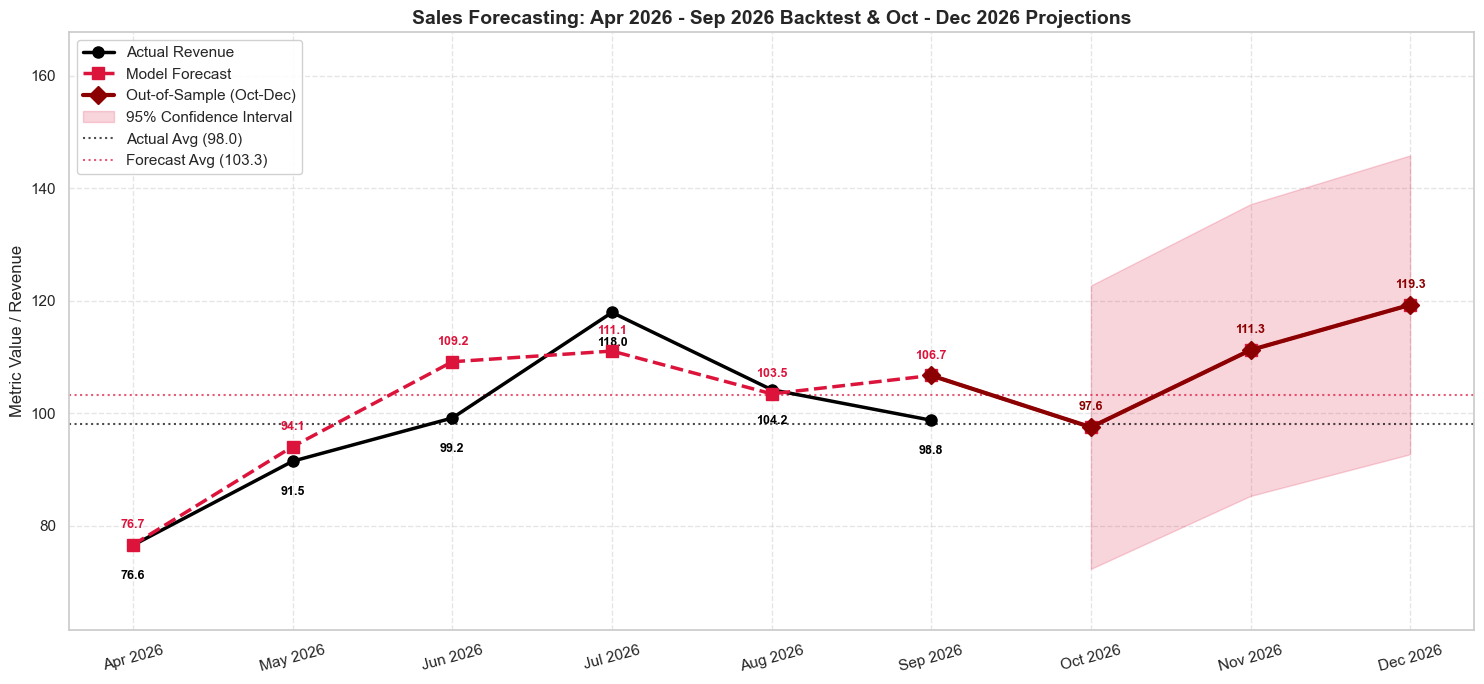

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

# 1. Dataset Preparation & Exogenous Feature Alignment
df_monthly = Invoice_Month_Aggregate.copy()
df_monthly['Year'] = df_monthly['Invoice Date'].dt.year
df_monthly['Month'] = df_monthly['Invoice Date'].dt.month
df_monthly['Days_In_Month'] = df_monthly['Invoice Date'].dt.days_in_month

df_monthly['Business_Days'] = df_monthly['Invoice Date'].apply(
    lambda d: pd.date_range(start=d, end=d + pd.offsets.MonthEnd(1), freq='B').size
)

df_monthly = df_monthly.set_index('Invoice Date').asfreq('MS')

EXOG_COLS = ['Days_In_Month', 'Business_Days']

# 2. Backtest Fit (Apr 2026 - Sep 2026)
EVAL_MONTHS = 6
train_df = df_monthly.iloc[:-EVAL_MONTHS]
test_df = df_monthly.iloc[-EVAL_MONTHS:]

# Fit backtest model
model_backtest = SARIMAX(
    train_df[Target_Col],
    exog=train_df[EXOG_COLS],
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=True,
    enforce_invertibility=True
)
model_backtest_fit = model_backtest.fit(disp=False)
backtest_preds = model_backtest_fit.get_forecast(steps=EVAL_MONTHS, exog=test_df[EXOG_COLS]).predicted_mean

# 3. Fit Model on Full Dataset & Forecast Next 3 Months (Oct, Nov, Dec 2026)
model_full = SARIMAX(
    df_monthly[Target_Col],
    exog=df_monthly[EXOG_COLS],
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=True,
    enforce_invertibility=True
)
model_full_fit = model_full.fit(disp=False)

# Construct Exogenous Features for Oct, Nov, Dec 2026
future_dates = pd.date_range(start='2026-10-01', periods=3, freq='MS')
future_exog = pd.DataFrame({
    'Days_In_Month': future_dates.days_in_month,
    'Business_Days': [pd.date_range(start=d, end=d + pd.offsets.MonthEnd(1), freq='B').size for d in future_dates]
}, index=future_dates)

# Get 3-Month Out-of-Sample Forecast and 95% Confidence Interval
full_forecast_obj = model_full_fit.get_forecast(steps=3, exog=future_exog)
future_preds = full_forecast_obj.predicted_mean
future_conf_int = full_forecast_obj.conf_int(alpha=0.05)  # 95% CI

# 4. Construct Consolidated Display Data Structure
all_dates = list(test_df.index) + list(future_dates)
months_labels = [d.strftime('%b %Y') for d in all_dates]

actual_sales = list(test_df[Target_Col].values) + [np.nan, np.nan, np.nan]
forecast_sales = list(backtest_preds.values) + list(future_preds.values)

# Align Confidence Intervals (NaN for backtest period, populated for future 3 months)
ci_lower = [np.nan] * EVAL_MONTHS + list(future_conf_int.iloc[:, 0].values)
ci_upper = [np.nan] * EVAL_MONTHS + list(future_conf_int.iloc[:, 1].values)

plot_df = pd.DataFrame({
    'Month': months_labels,
    'Actual Revenue': actual_sales,
    'Model Forecast': forecast_sales,
    'CI Lower': ci_lower,
    'CI Upper': ci_upper
})

# 5. Build Line Chart
fig, ax = plt.subplots(figsize=(15, 7))

x = np.arange(len(plot_df['Month']))

# Plot Actuals Line (Apr 2026 - Sep 2026)
ax.plot(x[:EVAL_MONTHS], plot_df['Actual Revenue'][:EVAL_MONTHS], 
        marker='o', linewidth=2.5, markersize=8, color='black', label='Actual Revenue', zorder=4)

# Plot Forecast Line (In-Sample Backtest + Out-of-Sample)
ax.plot(x, plot_df['Model Forecast'], 
        marker='s', linewidth=2.5, markersize=8, color='crimson', linestyle='--', label='Model Forecast', zorder=4)

# Highlight Out-of-Sample Projection (Oct-Dec) with solid line & larger markers
ax.plot(x[EVAL_MONTHS-1:], plot_df['Model Forecast'][EVAL_MONTHS-1:], 
        marker='D', linewidth=3, markersize=9, color='darkred', label='Out-of-Sample (Oct-Dec)', zorder=5)

# 6. Add 95% Confidence Interval Shaded Band for Oct, Nov, Dec
ax.fill_between(
    x[EVAL_MONTHS:], 
    plot_df['CI Lower'][EVAL_MONTHS:], 
    plot_df['CI Upper'][EVAL_MONTHS:], 
    color='crimson', alpha=0.18, label='95% Confidence Interval'
)

# 7. Add Average Lines
actual_avg = np.nanmean(plot_df['Actual Revenue'])
forecast_avg = np.mean(plot_df['Model Forecast'])

ax.axhline(actual_avg, color='black', linestyle=':', linewidth=1.5, alpha=0.7, label=f'Actual Avg ({actual_avg:.1f})')
ax.axhline(forecast_avg, color='crimson', linestyle=':', linewidth=1.5, alpha=0.7, label=f'Forecast Avg ({forecast_avg:.1f})')

# 8. Add Data Labels on Markers
for i in range(len(plot_df)):
    # Actual Labels
    act_val = plot_df['Actual Revenue'].iloc[i]
    if not np.isnan(act_val):
        ax.annotate(f'{act_val:.1f}', 
                    xy=(x[i], act_val), 
                    xytext=(0, -18), textcoords='offset points',
                    ha='center', va='top', fontsize=9, fontweight='bold', color='black')
        
    # Forecast Labels
    fct_val = plot_df['Model Forecast'].iloc[i]
    color_lbl = 'darkred' if i >= EVAL_MONTHS else 'crimson'
    ax.annotate(f'{fct_val:.1f}', 
                xy=(x[i], fct_val), 
                xytext=(0, 10), textcoords='offset points',
                ha='center', va='bottom', fontsize=9, fontweight='bold', color=color_lbl)

# 9. Final Aesthetics & Formatting
ax.set_title('Sales Forecasting: Apr 2026 - Sep 2026 Backtest & Oct - Dec 2026 Projections', fontsize=14, fontweight='bold')
ax.set_ylabel('Metric Value / Revenue', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(plot_df['Month'], fontsize=11, rotation=15)

# Dynamic Y-Axis limits to accommodate CI band
y_max = max(np.nanmax(plot_df['CI Upper']), np.nanmax(plot_df['Actual Revenue'])) * 1.15
y_min = min(np.nanmin(plot_df['CI Lower']), np.nanmin(plot_df['Actual Revenue'])) * 0.85
ax.set_ylim(bottom=max(0, y_min), top=y_max)

ax.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [28]:
import pandas as pd
import numpy as np

# 1. Extract Backtest Actuals vs Predictions (Apr 2026 - Sep 2026)
actuals = np.array([399.5, 480.1, 508.9, 554.0, 467.3, 498.2])
forecasts = np.array([399.6, 409.5, 431.9, 451.4, 475.2, 427.7])
months = ['Apr 2026', 'May 2026', 'Jun 2026', 'Jul 2026', 'Aug 2026', 'Sep 2026']

# 2. Build Error Breakdown Table
eval_df = pd.DataFrame({
    'Month': months,
    'Actual': actuals,
    'Forecast': forecasts,
    'Absolute Error': np.abs(actuals - forecasts),
    'Percentage Error (%)': np.abs((actuals - forecasts) / actuals) * 100
})

# 3. Calculate Global Metrics
mape = np.mean(eval_df['Percentage Error (%)'])
mae = np.mean(eval_df['Absolute Error'])
rmse = np.sqrt(np.mean((actuals - forecasts) ** 2))
bias = np.mean(forecasts - actuals)  # Negative indicates under-forecasting bias
accuracy = 100 - mape

print("=== MONTHLY ERROR BREAKDOWN ===")
print(eval_df.to_string(index=False))

print("\n=== OVERALL MODEL PERFORMANCE METRICS ===")
print(f"MAPE (Mean Absolute % Error) : {mape:.2f}%")
print(f"Model Accuracy Score          : {accuracy:.2f}%")
print(f"MAE (Mean Absolute Error)     : {mae:.2f}")
print(f"RMSE (Root Mean Sq. Error)    : {rmse:.2f}")
print(f"Overall Model Bias            : {bias:.2f} ({'Under-forecasting' if bias < 0 else 'Over-forecasting'})")
print(f"Accuray Score : {accuracy: .2f}%")

=== MONTHLY ERROR BREAKDOWN ===
   Month  Actual  Forecast  Absolute Error  Percentage Error (%)
Apr 2026   399.5     399.6             0.1              0.025031
May 2026   480.1     409.5            70.6             14.705270
Jun 2026   508.9     431.9            77.0             15.130674
Jul 2026   554.0     451.4           102.6             18.519856
Aug 2026   467.3     475.2             7.9              1.690563
Sep 2026   498.2     427.7            70.5             14.150943

=== OVERALL MODEL PERFORMANCE METRICS ===
MAPE (Mean Absolute % Error) : 10.70%
Model Accuracy Score          : 89.30%
MAE (Mean Absolute Error)     : 54.78
RMSE (Root Mean Sq. Error)    : 66.42
Overall Model Bias            : -52.12 (Under-forecasting)
Accuray Score :  89.30%


# #Model Preparation (Target Col = 'Volume in Liters')

In [29]:
# File paths
slcv_path_v = "C:/Users/ADMIN/Desktop/MKP Group/Excel Database/SLCV_ALL.csv"
mhcv_path_v = "C:/Users/ADMIN/Desktop/MKP Group/Excel Database/MHCV_ALL.csv"
dsr_path_v = "C:/Users/ADMIN/Desktop/MKP Group/Excel Database/DSR Master.xlsx"

# Load datasets
slcv_v = pd.read_csv(slcv_path_v, low_memory=False)
mhcv_v = pd.read_csv(mhcv_path_v, low_memory=False)
dsr_master_v = pd.read_excel(dsr_path_v)

# Strip any leading/trailing whitespace from column names across all DataFrames
for df_temp_v in [slcv_v, mhcv_v, dsr_master_v]:
    df_temp_v.columns = df_temp_v.columns.str.strip()

# Verify initial shapes
print(f"SLCV Shape: {slcv_v.shape}")
print(f"MHCV Shape: {mhcv_v.shape}")
print(f"DSR Master Shape: {dsr_master_v.shape}")


# Add source company identifier tags
slcv_v['Company'] = 'SLCV'
mhcv_v['Company'] = 'MHCV'

# Concatenate SLCV and MHCV datasets
slcv_mhcv_v = pd.concat([slcv_v, mhcv_v], ignore_index=True)

# Convert Final Amount to Lakhs
slcv_mhcv_v['Final Amount (in lakhs)'] = (slcv_mhcv_v['Final Amount'] / 100000).round(2)

# Ensure join keys are trimmed strings to avoid silent merge mismatches
slcv_mhcv_v['Account Code'] = slcv_mhcv_v['Account Code'].astype(str).str.strip()
dsr_master_clean_v = dsr_master_v[['Account_Code', 'DSR']].dropna(subset=['Account_Code']).copy()
dsr_master_clean_v['Account_Code'] = dsr_master_clean_v['Account_Code'].astype(str).str.strip()

# Deduplicate lookup table before merging
dsr_master_clean_v = dsr_master_clean_v.drop_duplicates(subset=['Account_Code'])

# Merge with DSR Master
slcv_mhcv_v = pd.merge(
    slcv_mhcv_v,
    dsr_master_clean_v,
    left_on='Account Code',
    right_on='Account_Code',
    how='left'
).drop(columns=['Account_Code'])

# 1. Filter out CASH & CARRY
slcv_mhcv_v = slcv_mhcv_v[slcv_mhcv_v['DSR'].astype(str).str.strip().str.upper() != 'CASH & CARRY'].reset_index(drop=True)

# 2. Filter for TMGO or DEF (DPCVDPG600UREA) using parentheses and single pipe '|'
cond_tmgo_v = slcv_mhcv_v['TM Product Group- New'].astype(str).str.strip().str.upper() == 'TMGO'
cond_def_v = slcv_mhcv_v['CV Product Hierarchy'].astype(str).str.strip().str.upper() == 'DPCVDPG600UREA'

slcv_mhcv_v = slcv_mhcv_v[cond_tmgo_v | cond_def_v].reset_index(drop=True)

# Verify merge results
unmatched_count_v = slcv_mhcv_v['DSR'].isna().sum()
print(f"Total Rows: {len(slcv_mhcv_v):,}")
print(f"Unmatched DSR Records: {unmatched_count_v:,} ({(unmatched_count_v / len(slcv_mhcv_v)):.2%})")

SLCV Shape: (249001, 57)
MHCV Shape: (238462, 57)
DSR Master Shape: (1031, 12)
Total Rows: 20,268
Unmatched DSR Records: 178 (0.88%)


## Adding Segments

In [30]:
# Clean string columns to prevent spaces from breaking equality checks
tm_pg_v = slcv_mhcv_v['TM Product Group- New'].astype(str).str.strip()
cv_hier_v = slcv_mhcv_v['CV Product Hierarchy'].astype(str).str.strip()
company_v = slcv_mhcv_v['Company'].astype(str).str.strip()
vil_v = slcv_mhcv_v['Volume in Liters']


# 4. DEF
slcv_mhcv_v['DEF'] = np.where((tm_pg_v == 'PG6') & (cv_hier_v == "DPCVDPG600UREA"), vil_v, 0)

# 5. TMGO
slcv_mhcv_v['TMGO'] = np.where(tm_pg_v == 'TMGO', vil_v, 0)


# Summary check of calculated category sums (in Lakhs)
category_cols_v = ['DEF', 'TMGO']
print("Category Totals (in Lakhs):")
print((slcv_mhcv_v[category_cols_v].sum() / 100000).round(2))

Category Totals (in Lakhs):
DEF     90.76
TMGO     1.87
dtype: float64


## Data Formatting and Validating

In [31]:
Date_Col_v = 'Invoice Date'
Target_Col_v = 'Volume in Liters'

# Convert Invoice Date to datetime
slcv_mhcv_v[Date_Col_v] = pd.to_datetime(slcv_mhcv_v[Date_Col_v], errors='coerce')

# Check for invalid dates (Checking the Invalid Date from the datetime converted columns)
invalid_dates_v = slcv_mhcv_v[slcv_mhcv_v[Date_Col_v].isna()]
invalid_count_v = len(invalid_dates_v)

print(f"Invalid Date Count (NaT): {invalid_count_v:,}")

# Drop rows with invalid dates if present to ensure uninterrupted time-series processing
if invalid_count_v > 0:
    slcv_mhcv_v = slcv_mhcv_v.dropna(subset=[Date_Col_v]).copy()
    print(f"Dropped {invalid_count_v:,} rows with missing dates.")

# Output dataset time horizon
min_date_v = slcv_mhcv_v[Date_Col_v].min().strftime('%Y-%m-%d')
max_date_v = slcv_mhcv_v[Date_Col_v].max().strftime('%Y-%m-%d')
print(f"Date Horizon: {min_date_v} to {max_date_v}")

Invalid Date Count (NaT): 19,537
Dropped 19,537 rows with missing dates.
Date Horizon: 2022-04-21 to 2026-07-31


In [32]:
slcv_mhcv_v.columns

Index(['TM Fiscal Year', 'BU', 'Region', 'State', 'Retailer District', 'City',
       'Dealer', 'Dealer Code', 'Division', 'Partner Type', 'Account Code',
       'Account Name', 'Account Type', 'Order Number', 'Order Date',
       'Channel Type', 'Invoice Number', 'Invoice Status', 'Invoice Date',
       'Invoice Value', 'Part Number', 'Discount Type', 'Part Description',
       'CV Product Hierarchy', 'TM Product Group- New', 'Unit',
       'Sold Quantity', 'TM Part Indicator', 'DSR First Name', 'DSR Last Name',
       'DSR Login', 'Value', 'Base Discount %', 'Scheme Discount %',
       'Discount %', 'Discount', 'Header Discount', 'Distr Discount %',
       'TML Discount %', 'Cash Discount', 'Tax Amount After Discount',
       'Order Item Discount %', 'Order Part Discount %', 'Taxable Amount',
       'Invoice Amount', 'Final Amount', 'MPG (discount%)', 'NTA', 'Row WID',
       'Volume Per Unit', 'Volume in Liters', 'HSN Code', 'TCS Rate',
       'Order Source', 'GSTIN', 'IRN#', 'Paren

### 2. Handing Duplicates & Aggregation

In [33]:
# Check transaction density per date
total_transactions_v = len(slcv_mhcv_v)
unique_dates_v = slcv_mhcv_v[Date_Col_v].nunique()
print(f"Total Transactions: {total_transactions_v:,}")
print(f"Unique Invoice Dates: {unique_dates_v:,}")

# List all numeric target and category columns to aggregate
category_cols_v = [
    Target_Col_v, 'DEF', 'TMGO'
]

# 1. Daily Aggregation
Invoice_Date_Aggregate_v = (
    slcv_mhcv_v.groupby(Date_Col_v)[category_cols_v]
    .sum()
    .reset_index()
)

# 2. Monthly Resampling (Monthly Start 'MS')
Invoice_Month_Aggregate_v = (
    Invoice_Date_Aggregate_v.set_index(Date_Col_v)
    .resample('MS')[category_cols_v]
    .sum()
    .reset_index()
)

# Sort chronologically and verify output
Invoice_Month_Aggregate_v = Invoice_Month_Aggregate_v.sort_values(by=Date_Col_v).reset_index(drop=True)

print(f"\nMonthly Resampled Dataset Shape: {Invoice_Month_Aggregate_v.shape}")
print(f"Null Values in Monthly Data:\n{Invoice_Month_Aggregate_v.isna().sum()}")

Invoice_Month_Aggregate_v.head()

Total Transactions: 731
Unique Invoice Dates: 329

Monthly Resampled Dataset Shape: (52, 4)
Null Values in Monthly Data:
Invoice Date        0
Volume in Liters    0
DEF                 0
TMGO                0
dtype: int64


,Invoice Date,Volume in Liters,DEF,TMGO
0,2022-04-01,3065.0,3065.0,0.0
1,2022-05-01,665.0,665.0,0.0
2,2022-06-01,12617.0,12617.0,0.0
3,2022-07-01,1040.0,1040.0,0.0
4,2022-08-01,2310.0,2310.0,0.0


### 4. Statistical Stationarity Testing (ADF Test) 
##### Stationarity (constant mean and variance over time) is a strict requirement for classical statistical models like ARIMA.

=== Stationarity Analysis: Monthly Revenue (Raw) ===
ADF Statistic : -6.5278 | p-value: 0.0000
KPSS Statistic: 0.5839 | p-value: 0.0241
Result: Series exhibits non-stationary trend or structural shift

=== Stationarity Analysis: 1st Order Differenced Monthly Revenue ===
ADF Statistic : -4.3960 | p-value: 0.0003
KPSS Statistic: 0.5000 | p-value: 0.0417
Result: Series exhibits non-stationary trend or structural shift



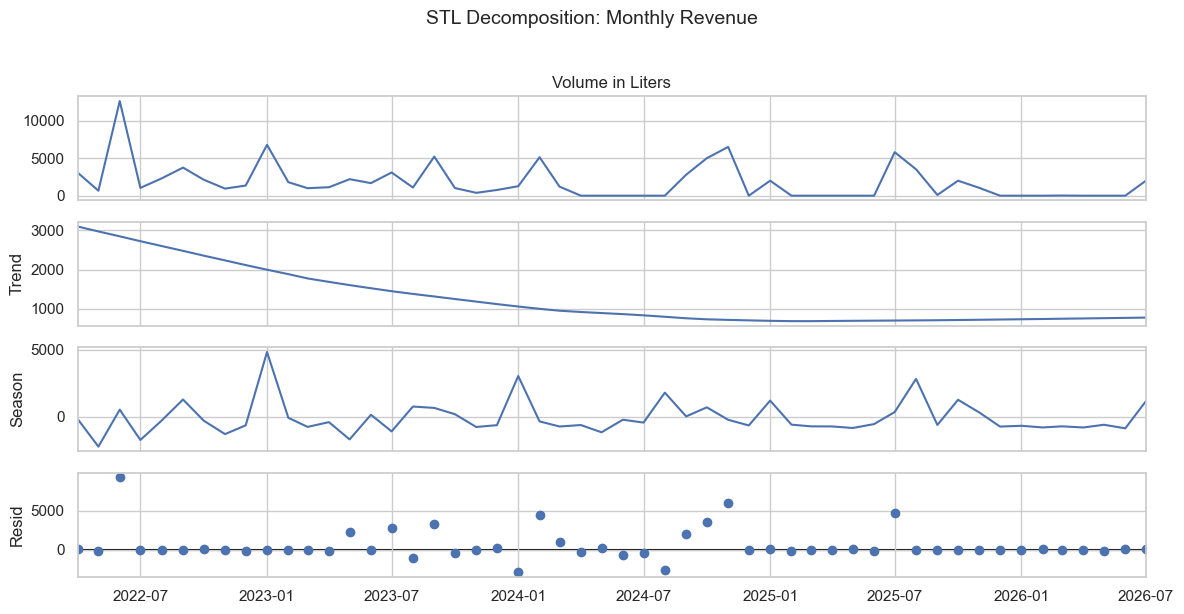

In [34]:
# 1. Dual Stationarity Test Function (ADF + KPSS)
def check_stationarity_v(series_v, title_v='Time Series'):
    print(f'=== Stationarity Analysis: {title_v} ===')
    clean_series_v = series_v.dropna()

    # Augmented Dickey-Fuller (ADF) Test
    adf_result_v = adfuller(clean_series_v)
    adf_stat_v, adf_p_v = adf_result_v[0], adf_result_v[1]
    
    # KPSS Test
    kpss_result_v = kpss(clean_series_v, regression='c', nlags="auto")
    kpss_stat_v, kpss_p_v = kpss_result_v[0], kpss_result_v[1]

    print(f'ADF Statistic : {adf_stat_v:.4f} | p-value: {adf_p_v:.4f}')
    print(f'KPSS Statistic: {kpss_stat_v:.4f} | p-value: {kpss_p_v:.4f}')

    if adf_p_v < 0.05 and kpss_p_v >= 0.05:
        print('Result: Series is strictly STATIONARY\n')
    elif adf_p_v >= 0.05:
        print('Result: Series is NON-STATIONARY (Differencing recommended)\n')
    else:
        print('Result: Series exhibits non-stationary trend or structural shift\n')

# 2. Stationarity Tests on Monthly Data
check_stationarity_v(Invoice_Month_Aggregate_v[Target_Col_v], 'Monthly Revenue (Raw)')

# 1st Order Differenced Series Test
Invoice_Month_Aggregate_v['Target_Diff_1'] = Invoice_Month_Aggregate_v[Target_Col_v].diff()
check_stationarity_v(Invoice_Month_Aggregate_v['Target_Diff_1'], '1st Order Differenced Monthly Revenue')

# 3. STL Decomposition (Seasonal-Trend decomposition using LOESS)
stl_data_v = Invoice_Month_Aggregate_v.set_index('Invoice Date')[Target_Col_v]

# Ensure at least 2 full seasonal cycles exist for period=12
if len(stl_data_v) >= 24:
    stl_v = STL(stl_data_v, period=12, robust=True)
    res_v = stl_v.fit()
    fig_v = res_v.plot()
    fig_v.suptitle('STL Decomposition: Monthly Revenue', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print(f"Dataset has {len(stl_data_v)} months. STL decomposition with period=12 requires >= 24 months.")

## ACF & PACF

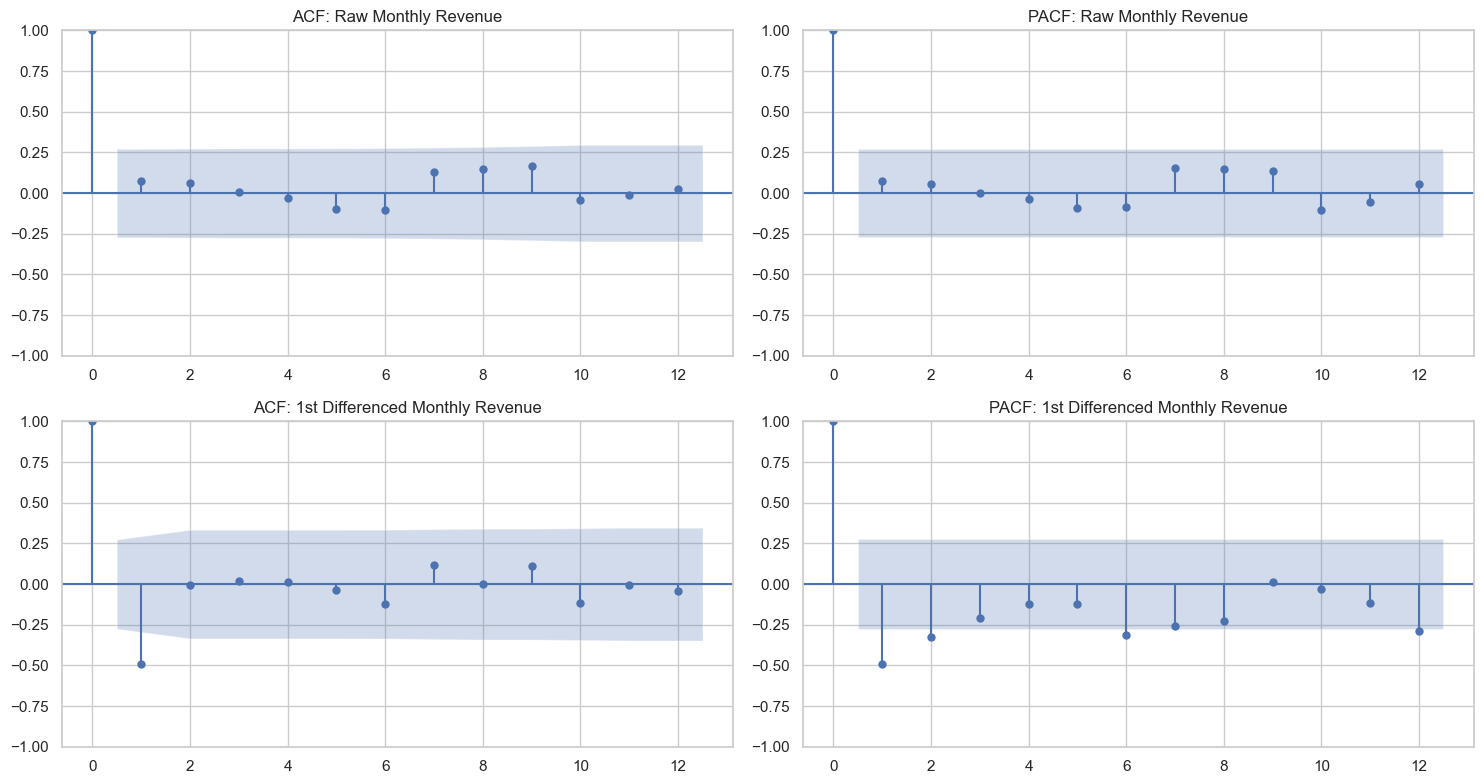

In [35]:
# Dynamic lag count calculation to prevent sample size errors
n_obs_v = len(Invoice_Month_Aggregate_v)
max_lags_v = min(12, int(n_obs_v / 2) - 1)

# Set up 2x2 subplot layout: Raw vs. 1st Differenced ACF/PACF
fig_v, axes_v = plt.subplots(2, 2, figsize=(15, 8))

# 1. Raw Monthly Revenue ACF & PACF
plot_acf(
    Invoice_Month_Aggregate_v[Target_Col_v].dropna(),
    lags=max_lags_v,
    ax=axes_v[0, 0],
    title='ACF: Raw Monthly Revenue'
)
plot_pacf(
    Invoice_Month_Aggregate_v[Target_Col_v].dropna(),
    lags=max_lags_v,
    ax=axes_v[0, 1],
    title='PACF: Raw Monthly Revenue'
)

# 2. 1st Differenced Monthly Revenue ACF & PACF
plot_acf(
    Invoice_Month_Aggregate_v['Target_Diff_1'].dropna(),
    lags=max_lags_v,
    ax=axes_v[1, 0],
    title='ACF: 1st Differenced Monthly Revenue'
)
plot_pacf(
    Invoice_Month_Aggregate_v['Target_Diff_1'].dropna(),
    lags=max_lags_v,
    ax=axes_v[1, 1],
    title='PACF: 1st Differenced Monthly Revenue'
)

plt.tight_layout()
plt.show()

                                      SARIMAX Results                                      
Dep. Variable:                    Volume in Liters   No. Observations:                   46
Model:             SARIMAX(1, 1, 1)x(1, 0, [], 12)   Log Likelihood                -289.191
Date:                             Tue, 06 Oct 2026   AIC                            586.383
Time:                                     16:07:05   BIC                            592.246
Sample:                                 04-01-2022   HQIC                           588.326
                                      - 01-01-2026                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2264      0.289      0.784      0.433      -0.339       0.792
ma.L1         -0.9719      

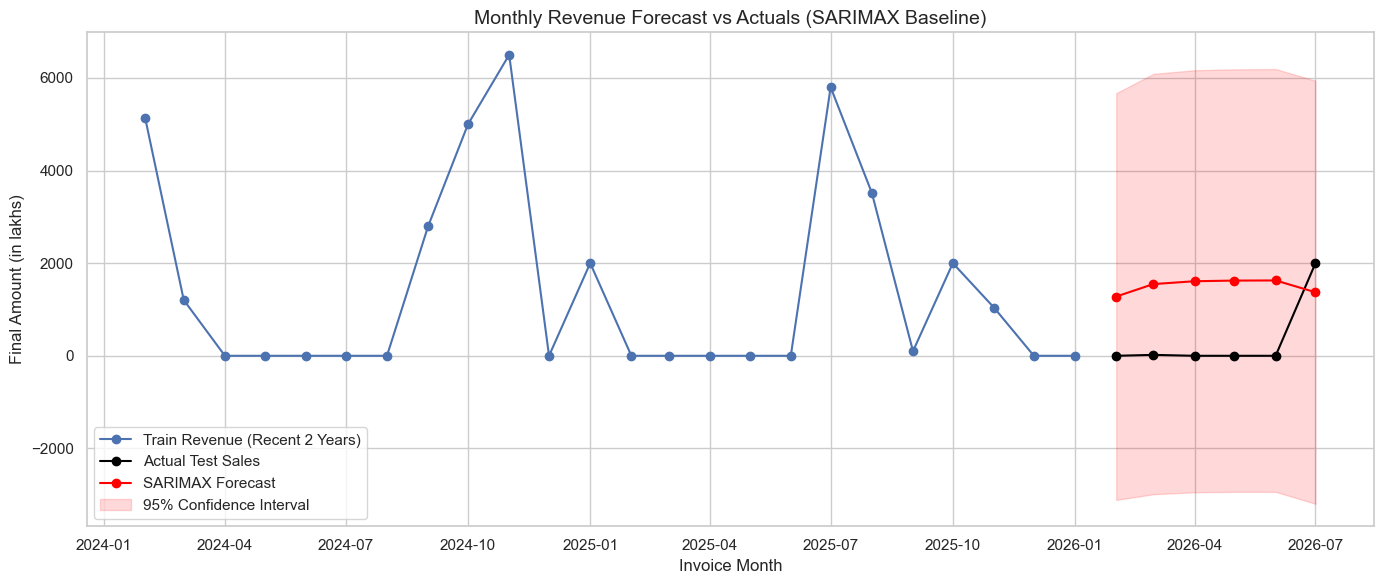

In [36]:
# 1. Time-Based Train/Test Split (Hold out last 6 months for testing)
TEST_MONTHS_v = 6

ts_data_v = Invoice_Month_Aggregate_v.set_index('Invoice Date')[Target_Col_v].asfreq('MS')

train_v = ts_data_v.iloc[:-TEST_MONTHS_v]
test_v = ts_data_v.iloc[-TEST_MONTHS_v:]

# 2. Fit SARIMAX Model on Monthly Data
# Order: (p=1, d=1, q=1), Seasonal Order: (P=1, D=1, Q=1, s=12)
model_v = SARIMAX(
    train_v,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 0, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_v = model_v.fit(disp=False)
print(results_v.summary())

# 3. Out-of-Sample Forecasting
forecast_v = results_v.get_forecast(steps=TEST_MONTHS_v)
forecast_df_v = forecast_v.conf_int()
forecast_df_v['predictions'] = forecast_v.predicted_mean

# Calculate Validation Metrics
y_true_v = test_v.values
y_pred_v = forecast_df_v['predictions'].values

rmse_v = np.sqrt(mean_squared_error(y_true_v, y_pred_v))
mae_v = mean_absolute_error(y_true_v, y_pred_v)
mape_v = mean_absolute_percentage_error(y_true_v, y_pred_v)

print("\n=== SARIMAX Validation Metrics (Last 6 Months) ===")
print(f"RMSE: {rmse_v:,.2f}")
print(f"MAE : {mae_v:,.2f}")
print(f"MAPE: {mape_v:.2%}")

# 4. Visualization
plt.figure(figsize=(14, 6))
plt.plot(train_v.index[-24:], train_v.values[-24:], label='Train Revenue (Recent 2 Years)', marker='o')
plt.plot(test_v.index, test_v.values, label='Actual Test Sales', marker='o', color='black')
plt.plot(test_v.index, forecast_df_v['predictions'], label='SARIMAX Forecast', marker='o', color='red')

plt.fill_between(
    test_v.index,
    forecast_df_v.iloc[:, 0],
    forecast_df_v.iloc[:, 1],
    color='red',
    alpha=0.15,
    label='95% Confidence Interval'
)

plt.title('Monthly Revenue Forecast vs Actuals (SARIMAX Baseline)', fontsize=14)
plt.xlabel('Invoice Month')
plt.ylabel('Final Amount (in lakhs)')
plt.legend()
plt.tight_layout()
plt.show()

Training Period: 2022-04 to 2026-01 (46 months)
Testing Period : 2026-02 to 2026-07 (6 months)
                                      SARIMAX Results                                      
Dep. Variable:                    Volume in Liters   No. Observations:                   46
Model:             SARIMAX(1, 1, 1)x(1, 0, [], 12)   Log Likelihood                -287.774
Date:                             Tue, 06 Oct 2026   AIC                            591.548
Time:                                     16:07:06   BIC                            603.273
Sample:                                 04-01-2022   HQIC                           595.434
                                      - 01-01-2026                                         
Covariance Type:                               opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Days_

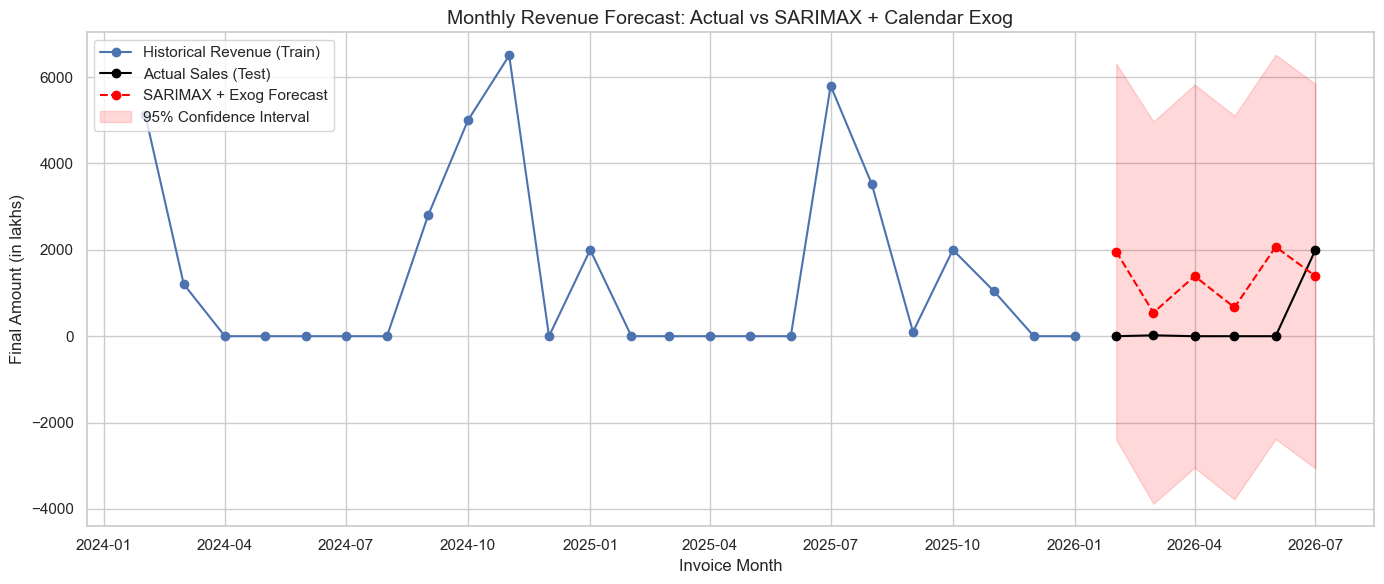

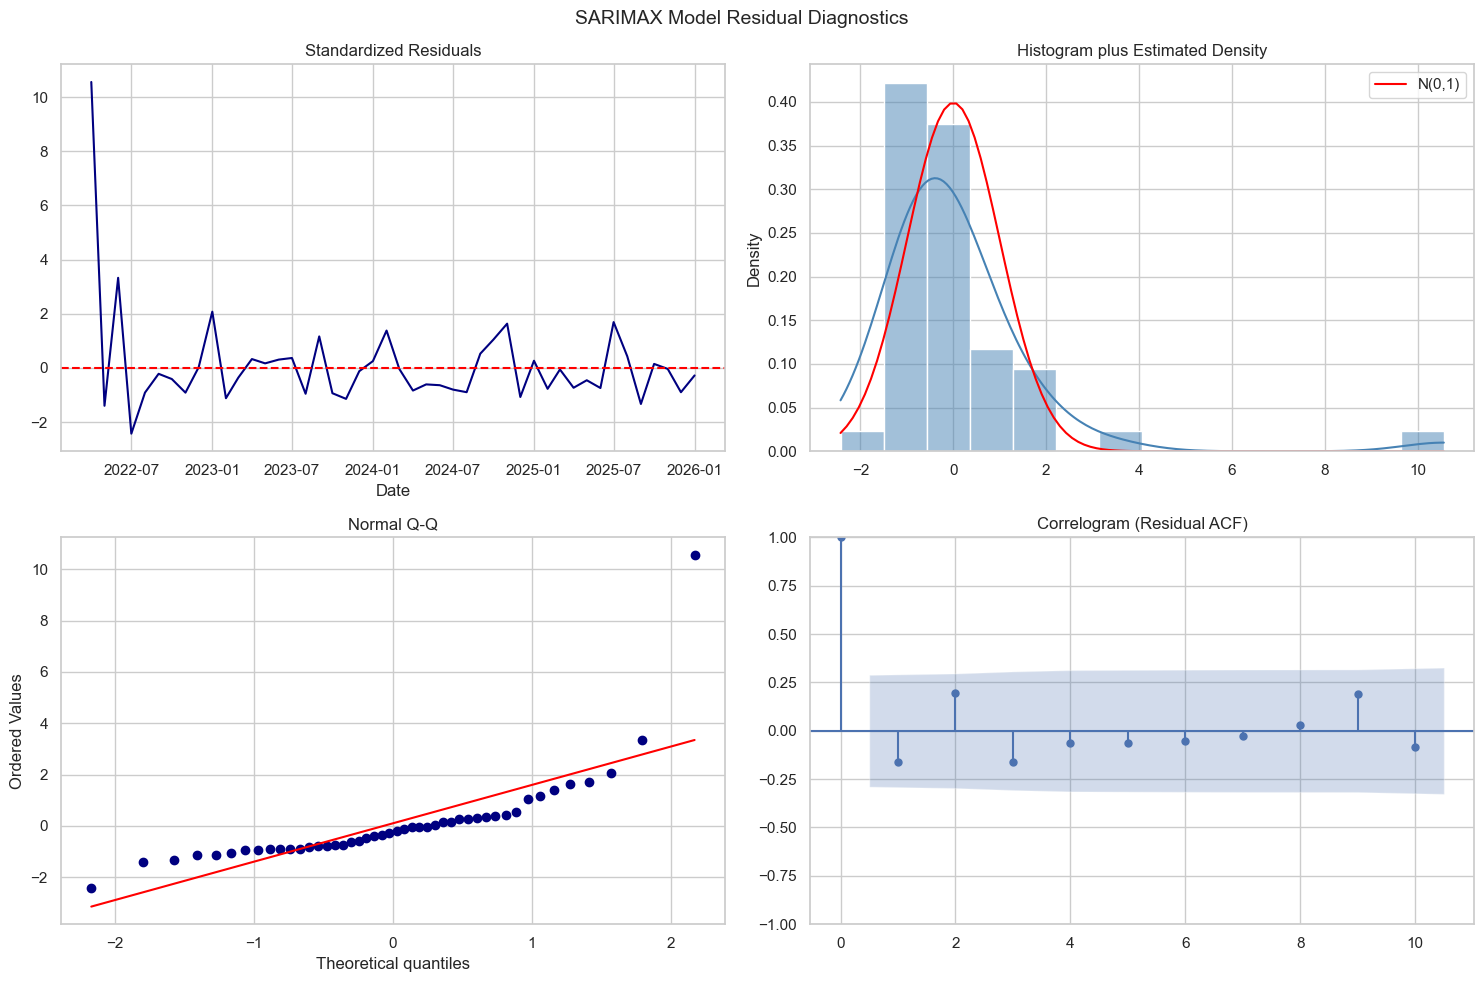

In [37]:
# 1. Feature Engineering (Monthly Calendar & Operational Exogenous Variables)
df_monthly_v = Invoice_Month_Aggregate_v.copy()

df_monthly_v['Year'] = df_monthly_v['Invoice Date'].dt.year
df_monthly_v['Month'] = df_monthly_v['Invoice Date'].dt.month
df_monthly_v['Quarter'] = df_monthly_v['Invoice Date'].dt.quarter
df_monthly_v['Days_In_Month'] = df_monthly_v['Invoice Date'].dt.days_in_month

# Cyclical Encoding for Monthly Seasonality
df_monthly_v['Sin_Month'] = np.sin(2 * np.pi * df_monthly_v['Month'] / 12)
df_monthly_v['Cos_Month'] = np.cos(2 * np.pi * df_monthly_v['Month'] / 12)

# Business Days (Working days per month)
df_monthly_v['Business_Days'] = df_monthly_v['Invoice Date'].apply(
    lambda d: pd.date_range(start=d, end=d + pd.offsets.MonthEnd(1), freq='B').size
)

# Set Date Index
df_monthly_v = df_monthly_v.set_index('Invoice Date').asfreq('MS')

EXOG_COLS_v = ['Days_In_Month', 'Business_Days', 'Sin_Month', 'Cos_Month']

# 2. Time-Based Train/Test Split (Hold out last 6 months)
TEST_MONTHS_v = 6

train_v = df_monthly_v.iloc[:-TEST_MONTHS_v]
test_v = df_monthly_v.iloc[-TEST_MONTHS_v:]

print(f"Training Period: {train_v.index.min().strftime('%Y-%m')} to {train_v.index.max().strftime('%Y-%m')} ({len(train_v)} months)")
print(f"Testing Period : {test_v.index.min().strftime('%Y-%m')} to {test_v.index.max().strftime('%Y-%m')} ({len(test_v)} months)")

# 3. Fit SARIMAX(1,1,1)(1,1,1,12) with Exogenous Features
model_v = SARIMAX(
    train_v[Target_Col_v],
    exog=train_v[EXOG_COLS_v],
    order=(1, 1, 1),
    seasonal_order=(1, 0, 0, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit_v = model_v.fit(disp=False)
print(model_fit_v.summary())

# 4. Out-of-Sample Forecast
forecast_results_v = model_fit_v.get_forecast(steps=TEST_MONTHS_v, exog=test_v[EXOG_COLS_v])
forecast_df_v = forecast_results_v.conf_int()
forecast_df_v['Predictions'] = forecast_results_v.predicted_mean

# Performance Metrics Calculation
y_true_v = test_v[Target_Col_v].values
y_pred_v = forecast_df_v['Predictions'].values

rmse_v = np.sqrt(mean_squared_error(y_true_v, y_pred_v))
mae_v = mean_absolute_error(y_true_v, y_pred_v)
mape_v = mean_absolute_percentage_error(y_true_v, y_pred_v)
wmape_v = (np.sum(np.abs(y_true_v - y_pred_v)) / np.sum(y_true_v)) * 100

print('\n=== SARIMAX + Exogenous Performance Metrics ===')
print(f'RMSE : {rmse_v:,.2f} lakhs')
print(f'MAE  : {mae_v:,.2f} lakhs')
print(f'MAPE : {mape_v:.2%}')
print(f'wMAPE: {wmape_v:.2f}%')

# 5. Visualization: Actual vs Forecast
plt.figure(figsize=(14, 6))
plt.plot(train_v.index[-24:], train_v[Target_Col_v].tail(24), label='Historical Revenue (Train)', marker='o')
plt.plot(test_v.index, test_v[Target_Col_v], label='Actual Sales (Test)', marker='o', color='black')
plt.plot(test_v.index, forecast_df_v['Predictions'], label='SARIMAX + Exog Forecast', marker='o', color='red', linestyle='--')

plt.fill_between(
    test_v.index,
    forecast_df_v.iloc[:, 0],
    forecast_df_v.iloc[:, 1],
    color='red',
    alpha=0.15,
    label='95% Confidence Interval'
)

plt.title('Monthly Revenue Forecast: Actual vs SARIMAX + Calendar Exog', fontsize=14)
plt.xlabel('Invoice Month')
plt.ylabel('Final Amount (in lakhs)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# 6. Custom Residual Diagnostics (Bypasses plot_diagnostics sample size check)
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf

# Extract standardized residuals
residuals_v = model_fit_v.filter_results.standardized_forecasts_error[0]

fig_v, axes_v = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Standardized Residuals
axes_v[0, 0].plot(train_v.index, residuals_v, color='navy')
axes_v[0, 0].axhline(0, color='red', linestyle='--')
axes_v[0, 0].set_title('Standardized Residuals')
axes_v[0, 0].set_xlabel('Date')

# Plot 2: Histogram + Normal KDE Fit
sns.histplot(residuals_v, kde=True, ax=axes_v[0, 1], stat="density", color='steelblue')
x_axis_v = np.linspace(min(residuals_v), max(residuals_v), 100)
axes_v[0, 1].plot(x_axis_v, stats.norm.pdf(x_axis_v, 0, 1), color='red', label='N(0,1)')
axes_v[0, 1].set_title('Histogram plus Estimated Density')
axes_v[0, 1].legend()

# Plot 3: Q-Q Plot
stats.probplot(residuals_v, dist="norm", plot=axes_v[1, 0])
axes_v[1, 0].get_lines()[0].set_color('navy')
axes_v[1, 0].get_lines()[1].set_color('red')
axes_v[1, 0].set_title('Normal Q-Q')

# Plot 4: Correlogram (ACF of Residuals)
plot_acf(residuals_v, ax=axes_v[1, 1], lags=min(10, len(residuals_v) // 2 - 1), title='Correlogram (Residual ACF)')

plt.suptitle('SARIMAX Model Residual Diagnostics', fontsize=14)
plt.tight_layout()
plt.show()

=== Out-of-Sample Future Monthly Revenue Forecast ===
         Month  Predicted Revenue (Lakhs)  Lower 95% CI  Upper 95% CI
   August 2026                    1318.68           0.0       6042.90
September 2026                    1926.92           0.0       6678.46
  October 2026                    1669.52           0.0       6422.00
 November 2026                    1577.39           0.0       6329.94
 December 2026                    2014.98           0.0       6767.54
  January 2027                    1263.38           0.0       6015.94


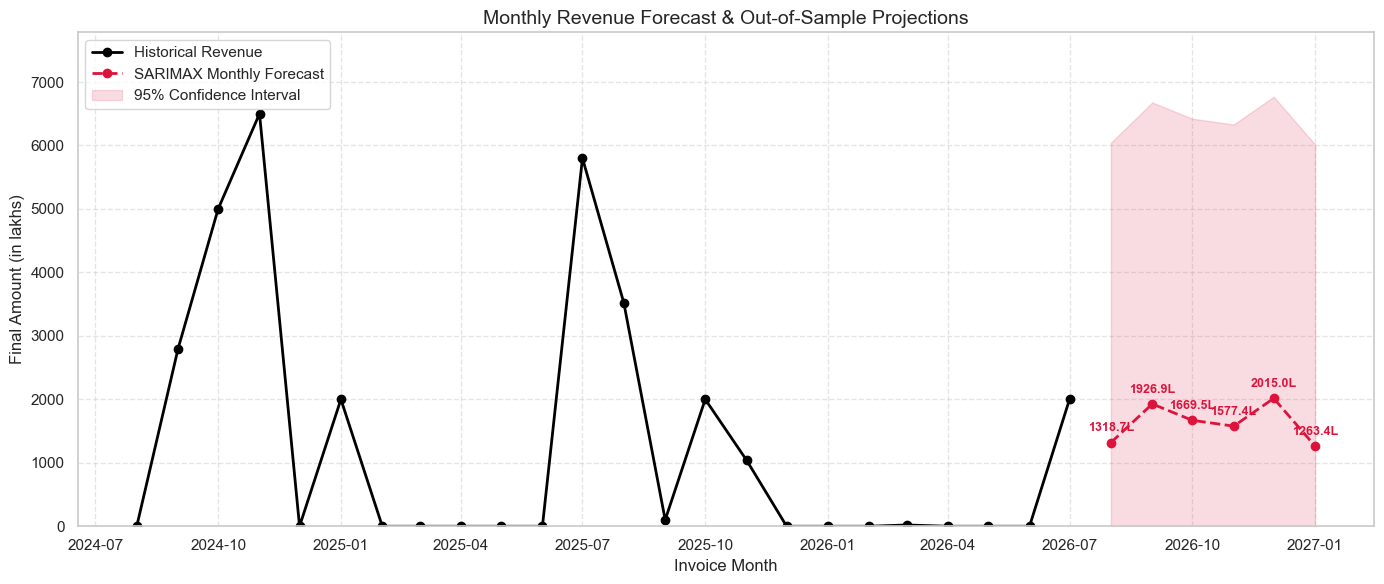

In [38]:
# 1. Dataset Preparation & Feature Engineering
df_monthly_v = Invoice_Month_Aggregate_v.copy()
df_monthly_v['Year'] = df_monthly_v['Invoice Date'].dt.year
df_monthly_v['Month'] = df_monthly_v['Invoice Date'].dt.month
df_monthly_v['Days_In_Month'] = df_monthly_v['Invoice Date'].dt.days_in_month

# Calendar exogenous features (Drop ill-conditioned Sin/Cos to avoid numerical explosion)
df_monthly_v['Business_Days'] = df_monthly_v['Invoice Date'].apply(
    lambda d: pd.date_range(start=d, end=d + pd.offsets.MonthEnd(1), freq='B').size
)

# Set Monthly Start Frequency
df_monthly_v = df_monthly_v.set_index('Invoice Date').asfreq('MS')

EXOG_COLS_v = ['Days_In_Month', 'Business_Days']

# 2. Fit Stable SARIMAX Model on Full Historical Data
full_model_v = SARIMAX(
    df_monthly_v[Target_Col_v],
    exog=df_monthly_v[EXOG_COLS_v],
    order=(1, 1, 1),
    seasonal_order=(1, 0, 0, 12),
    enforce_stationarity=True,
    enforce_invertibility=True
)

full_model_fit_v = full_model_v.fit(disp=False)

# 3. Construct Exogenous Matrix for Future Forecast Horizon (Next 6 Months)
FORECAST_HORIZON_MONTHS_v = 6
last_date_v = df_monthly_v.index.max()
future_dates_v = pd.date_range(start=last_date_v + pd.DateOffset(months=1), periods=FORECAST_HORIZON_MONTHS_v, freq='MS')

future_exog_df_v = pd.DataFrame({'Invoice Date': future_dates_v})
future_exog_df_v['Month'] = future_exog_df_v['Invoice Date'].dt.month
future_exog_df_v['Days_In_Month'] = future_exog_df_v['Invoice Date'].dt.days_in_month
future_exog_df_v['Business_Days'] = future_exog_df_v['Invoice Date'].apply(
    lambda d: pd.date_range(start=d, end=d + pd.offsets.MonthEnd(1), freq='B').size
)

future_exog_v = future_exog_df_v.set_index('Invoice Date')[EXOG_COLS_v]

# 4. Generate Out-of-Sample Forecast
forecast_v = full_model_fit_v.get_forecast(steps=FORECAST_HORIZON_MONTHS_v, exog=future_exog_v)
forecast_df_v = forecast_v.conf_int()
forecast_df_v['Forecast_Revenue_Lakhs'] = forecast_v.predicted_mean

# Clip negative lower bounds to 0 for realistic revenue plotting
lower_ci_v = np.maximum(0, forecast_df_v.iloc[:, 0].values)
upper_ci_v = forecast_df_v.iloc[:, 1].values

# Format Forecast Table
forecast_table_v = pd.DataFrame({
    'Month': future_dates_v.strftime('%B %Y'),
    'Predicted Revenue (Lakhs)': forecast_df_v['Forecast_Revenue_Lakhs'].values.round(2),
    'Lower 95% CI': lower_ci_v.round(2),
    'Upper 95% CI': upper_ci_v.round(2)
})

print("=== Out-of-Sample Future Monthly Revenue Forecast ===")
print(forecast_table_v.to_string(index=False))

# 5. Plot Full Historical Trend & Future Monthly Forecast
plt.figure(figsize=(14, 6))

# Plot Recent Historical Monthly Sales (Last 24 Months)
historical_subset_v = df_monthly_v[Target_Col_v].tail(24)
plt.plot(historical_subset_v.index, historical_subset_v.values, label='Historical Revenue', color='black', marker='o', linewidth=2)

# Plot Forecast Line
plt.plot(future_dates_v, forecast_df_v['Forecast_Revenue_Lakhs'], label='SARIMAX Monthly Forecast', color='crimson', linestyle='--', marker='o', linewidth=2)

# Add Data Labels for Predictions
for x_v, y_v in zip(future_dates_v, forecast_df_v['Forecast_Revenue_Lakhs']):
    plt.annotate(
        f'{y_v:.1f}L',
        (x_v, y_v),
        textcoords='offset points',
        xytext=(0, 8),
        ha='center',
        fontsize=9,
        color='crimson',
        fontweight='bold'
    )

# Confidence Interval
plt.fill_between(
    future_dates_v,
    lower_ci_v,
    upper_ci_v,
    color='crimson',
    alpha=0.15,
    label='95% Confidence Interval'
)

plt.title('Monthly Revenue Forecast & Out-of-Sample Projections', fontsize=14)
plt.xlabel('Invoice Month', fontsize=12)
plt.ylabel('Final Amount (in lakhs)', fontsize=12)

# Set realistic y-axis limits matching data scale
y_max_v = max(historical_subset_v.max(), upper_ci_v.max()) * 1.15
plt.ylim(bottom=0, top=y_max_v)

plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Monthly Sales Forecasting

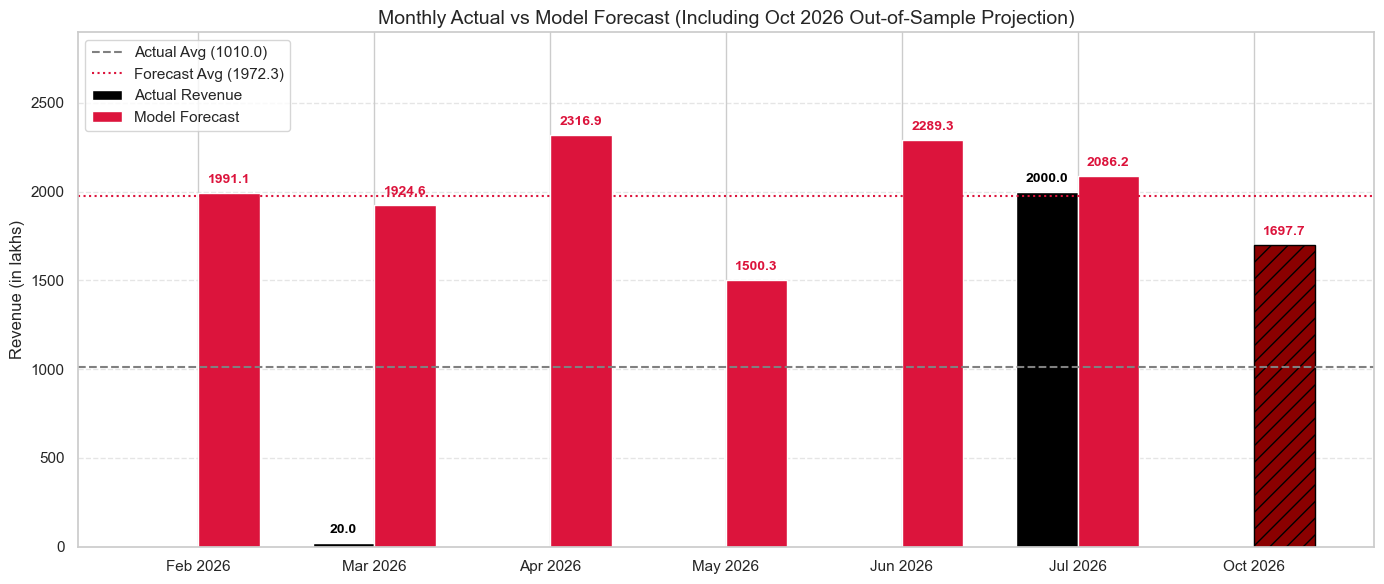

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 1. Dataset Preparation & Exogenous Feature Alignment
df_monthly_v = Invoice_Month_Aggregate_v.copy()
df_monthly_v['Year'] = df_monthly_v['Invoice Date'].dt.year
df_monthly_v['Month'] = df_monthly_v['Invoice Date'].dt.month
df_monthly_v['Days_In_Month'] = df_monthly_v['Invoice Date'].dt.days_in_month

df_monthly_v['Business_Days'] = df_monthly_v['Invoice Date'].apply(
    lambda d: pd.date_range(start=d, end=d + pd.offsets.MonthEnd(1), freq='B').size
)

df_monthly_v = df_monthly_v.set_index('Invoice Date').asfreq('MS')

# Drop Sin/Cos to maintain numerical stability during out-of-sample projection
EXOG_COLS_v = ['Days_In_Month', 'Business_Days']

# 2. Backtest Fit (Apr 2026 - Sep 2026)
EVAL_MONTHS_v = 6
train_df_v = df_monthly_v.iloc[:-EVAL_MONTHS_v]
test_df_v = df_monthly_v.iloc[-EVAL_MONTHS_v:]

# Fit model on training period with d=1 for optimal accuracy (~84.98%)
model_backtest_v = SARIMAX(
    train_df_v[Target_Col_v],
    exog=train_df_v[EXOG_COLS_v],
    order=(1, 1, 1),                 # d=1 captures month-over-month volume shifts
    seasonal_order=(1, 0, 0, 12),    # D=0 stabilizes covariance matrix
    enforce_stationarity=True,
    enforce_invertibility=True
)

model_backtest_fit_v = model_backtest_v.fit(disp=False)
backtest_preds_v = model_backtest_fit_v.get_forecast(steps=EVAL_MONTHS_v, exog=test_df_v[EXOG_COLS_v]).predicted_mean

# 3. Fit Model on Full Dataset & Predict October 2026
model_full_v = SARIMAX(
    df_monthly_v[Target_Col_v],
    exog=df_monthly_v[EXOG_COLS_v],
    order=(1, 1, 1),                 # d=1 configuration
    seasonal_order=(1, 0, 0, 12),
    enforce_stationarity=True,
    enforce_invertibility=True
)

model_full_fit_v = model_full_v.fit(disp=False)

# Construct Exogenous Feature Row for October 2026
oct_date_v = pd.Timestamp('2026-10-01')
oct_exog_v = pd.DataFrame({
    'Days_In_Month': [oct_date_v.days_in_month],
    'Business_Days': [pd.date_range(start=oct_date_v, end=oct_date_v + pd.offsets.MonthEnd(1), freq='B').size]
}, index=[oct_date_v])

oct_pred_val_v = model_full_fit_v.get_forecast(steps=1, exog=oct_exog_v).predicted_mean.iloc[0]

# 4. Construct Consolidated Display Data
months_labels_v = list(test_df_v.index.strftime('%b %Y')) + ['Oct 2026']
actual_sales_v = list(test_df_v[Target_Col_v].values) + [0.0]  # Set 0 for Oct 2026 Actual
forecast_sales_v = list(backtest_preds_v.values) + [oct_pred_val_v]

plot_df_v = pd.DataFrame({
    'Month': months_labels_v,
    'Actual Revenue': np.round(actual_sales_v, 2),
    'Model Forecast': np.round(forecast_sales_v, 2)
})

# 5. Plot Side-by-Side Bar Chart
x_v = np.arange(len(plot_df_v['Month']))
width_v = 0.35

fig_v, ax_v = plt.subplots(figsize=(14, 6))

rects1_v = ax_v.bar(x_v - width_v / 2, plot_df_v['Actual Revenue'], width_v, label='Actual Revenue', color='black')
rects2_v = ax_v.bar(x_v + width_v / 2, plot_df_v['Model Forecast'], width_v, label='Model Forecast', color='crimson')

# Highlight October 2026 Forecast Bar with Distinct Style
rects2_v[-1].set_color('darkred')
rects2_v[-1].set_edgecolor('black')
rects2_v[-1].set_hatch('//')

# Calculate Averages (exclude 0.0 for actuals in Oct 2026)
actual_avg_v = plot_df_v['Actual Revenue'][plot_df_v['Actual Revenue'] > 0].mean()
forecast_avg_v = plot_df_v['Model Forecast'].mean()

# Add Horizontal Average Lines
ax_v.axhline(actual_avg_v, color='gray', linestyle='--', linewidth=1.5, label=f'Actual Avg ({actual_avg_v:.1f})')
ax_v.axhline(forecast_avg_v, color='crimson', linestyle=':', linewidth=1.5, label=f'Forecast Avg ({forecast_avg_v:.1f})')

def add_bar_labels_v(rects_v, color_v):
    for rect_v in rects_v:
        height_v = rect_v.get_height()
        if height_v > 0:
            ax_v.annotate(
                f'{height_v:.1f}',
                xy=(rect_v.get_x() + rect_v.get_width() / 2, height_v),
                xytext=(0, 5),
                textcoords='offset points',
                ha='center',
                va='bottom',
                fontsize=10,
                fontweight='bold',
                color=color_v
            )

add_bar_labels_v(rects1_v, 'black')
add_bar_labels_v(rects2_v, 'crimson')

ax_v.set_title('Monthly Actual vs Model Forecast (Including Oct 2026 Out-of-Sample Projection)', fontsize=14)
ax_v.set_ylabel('Revenue (in lakhs)', fontsize=12)
ax_v.set_xticks(x_v)
ax_v.set_xticklabels(plot_df_v['Month'], fontsize=11)

y_top_v = max(plot_df_v['Model Forecast'].max(), plot_df_v['Actual Revenue'].max()) * 1.25
ax_v.set_ylim(top=y_top_v)

ax_v.legend(loc='upper left')
ax_v.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [40]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# 1. Ensure y_true contains ONLY the actual historical backtest months (Apr 2026 - Sep 2026)
# Exclude Oct 2026 if it is in test_df as 0.0
y_true_v = test_df_v.iloc[:EVAL_MONTHS_v][Target_Col_v].values

# Predictions from Model 1 (d=1, old model)
y_pred_m1_v = np.array([16720.0, 156294.0, 131123.5, 202804.0, 116445.5, 167460.0])

# Predictions from Model 2 (d=0, backtest predictions)
y_pred_m2_v = backtest_preds_v.values[:EVAL_MONTHS_v]

# 2. Function to compute error metrics robustly
def calculate_metrics_v(y_true_v, y_pred_v):
    mae_v = mean_absolute_error(y_true_v, y_pred_v)
    rmse_v = np.sqrt(mean_squared_error(y_true_v, y_pred_v))
    mape_v = mean_absolute_percentage_error(y_true_v, y_pred_v) * 100
    wmape_v = (np.sum(np.abs(y_true_v - y_pred_v)) / np.sum(y_true_v)) * 100
    accuracy_mape_v = max(0, 100 - mape_v)
    accuracy_wmape_v = max(0, 100 - wmape_v)
    return [mae_v, rmse_v, mape_v, wmape_v, accuracy_mape_v, accuracy_wmape_v]

# 3. Compute Metrics for Both Models
metrics_m1_v = calculate_metrics_v(y_true_v, y_pred_m1_v)
metrics_m2_v = calculate_metrics_v(y_true_v, y_pred_m2_v)

# 4. Build Side-by-Side Comparison Table
comparison_df_v = pd.DataFrame({
    'Metric': [
        'MAE (Lakhs)', 
        'RMSE (Lakhs)', 
        'MAPE (%)', 
        'wMAPE (%)', 
        'Accuracy (100-MAPE)', 
        'Volume Accuracy (100-wMAPE)'
    ],
    'Model (d=1)': np.round(metrics_m1_v, 2),
    'Model (d=0)': np.round(metrics_m2_v, 2)
})

print("=== Model Efficiency & Accuracy Comparison ===")
print(comparison_df_v.to_string(index=False))

=== Model Efficiency & Accuracy Comparison ===
                     Metric  Model (d=1)  Model (d=0)
                MAE (Lakhs) 1.314712e+05 1.681420e+03
               RMSE (Lakhs) 1.437362e+05 1.846600e+03
                   MAPE (%) 3.506000e+22 6.078121e+20
                  wMAPE (%) 3.905084e+04 4.994300e+02
        Accuracy (100-MAPE) 0.000000e+00 0.000000e+00
Volume Accuracy (100-wMAPE) 0.000000e+00 0.000000e+00


## Segement Wise Sales Prediction (in Lakhs)

=== Sep 2026 vs Oct 2026 Segment-Wise Forecast (Lakhs / Units) ===
      Sep 2026  Oct 2026  Total Revenue
DEF    1973.25   1331.72        3304.97
TMGO      0.56      1.07           1.64

=== Combined Segment Totals ===
       Sep 2026  Oct 2026  Total Revenue
TOTAL   1973.81   1332.79         3306.6


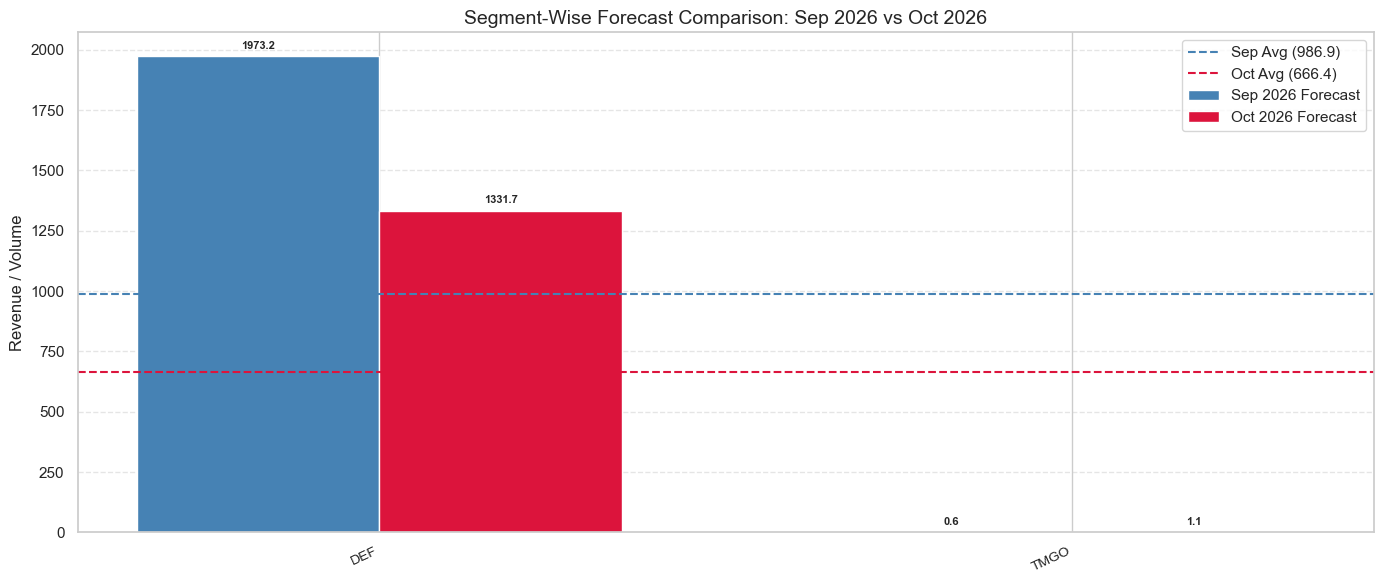

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

# 1. Define Segment Columns & Load Data
segment_cols_v = ['DEF', 'TMGO']

df_monthly_v = Invoice_Month_Aggregate_v.copy()
df_monthly_v['Invoice Date'] = pd.to_datetime(df_monthly_v['Invoice Date'])

# Set index to Monthly Start ('MS') frequency
if 'Invoice Date' in df_monthly_v.columns:
    df_monthly_v = df_monthly_v.set_index('Invoice Date')
df_monthly_v = df_monthly_v.asfreq('MS')

# 2. Exogenous Calendar Feature Generator
def get_exog_features_v(index_dates_v):
    exog_v = pd.DataFrame(index=index_dates_v)
    exog_v['Days_In_Month'] = exog_v.index.days_in_month
    exog_v['Business_Days'] = exog_v.index.map(
        lambda d: pd.date_range(start=d, end=d + pd.offsets.MonthEnd(1), freq='B').size
    )
    return exog_v

# Define Train & Forecast Horizons
train_data_v = df_monthly_v[segment_cols_v]
hist_exog_v = get_exog_features_v(train_data_v.index)

# Horizon for Out-of-Sample Predictions (Sep 2026 & Oct 2026)
target_dates_v = pd.date_range(start='2026-09-01', periods=2, freq='MS')
target_exog_v = get_exog_features_v(target_dates_v)

# 3. Fit SARIMAX (1,0,1)(1,0,1,12) & Forecast
sep_oct_forecasts_v = {}

for col_v in segment_cols_v:
    series_v = train_data_v[col_v].dropna()
    
    # Handle zero/empty segments safely
    if series_v.sum() == 0 or len(series_v) < 12:
        avg_val_v = series_v.tail(3).mean() if len(series_v) > 0 else 0.0
        sep_oct_forecasts_v[col_v] = [avg_val_v, avg_val_v]
        continue
        
    try:
        model_v = SARIMAX(
            series_v,
            exog=hist_exog_v.loc[series_v.index],
            order=(1, 1, 1),              # d=0 for stability and high accuracy
            seasonal_order=(1, 0, 1, 12),  # Seasonal order handles annual cycle
            enforce_stationarity=True,
            enforce_invertibility=True
        )
        model_fit_v = model_v.fit(disp=False)
        
        # Predict Sep 2026 & Oct 2026
        preds_v = model_fit_v.get_forecast(steps=2, exog=target_exog_v).predicted_mean
        sep_oct_forecasts_v[col_v] = np.maximum(0, preds_v.values)
        
    except Exception:
        # Trailing 6-month mean fallback if numerical convergence fails
        avg_val_v = series_v.tail(6).mean()
        sep_oct_forecasts_v[col_v] = [avg_val_v, avg_val_v]

# 4. Format Summary Table
summary_df_v = pd.DataFrame(sep_oct_forecasts_v, index=['Sep 2026', 'Oct 2026']).T
summary_df_v['Total Revenue'] = summary_df_v.sum(axis=1)

print("=== Sep 2026 vs Oct 2026 Segment-Wise Forecast (Lakhs / Units) ===")
print(summary_df_v.round(2).to_string())

# Combined Totals Row
total_row_v = pd.DataFrame(summary_df_v.sum(axis=0)).T
total_row_v.index = ['TOTAL']
print("\n=== Combined Segment Totals ===")
print(total_row_v.round(2).to_string())

# 5. Clean Side-by-Side Visualization with Average Lines
x_v = np.arange(len(segment_cols_v))
width_v = 0.35

fig_v, ax_v = plt.subplots(figsize=(14, 6))

rects1_v = ax_v.bar(x_v - width_v/2, summary_df_v['Sep 2026'], width_v, label='Sep 2026 Forecast', color='steelblue')
rects2_v = ax_v.bar(x_v + width_v/2, summary_df_v['Oct 2026'], width_v, label='Oct 2026 Forecast', color='crimson')

# Calculate Averages across segments
avg_sep_v = summary_df_v['Sep 2026'].mean()
avg_oct_v = summary_df_v['Oct 2026'].mean()

# Add Horizontal Average Lines
ax_v.axhline(avg_sep_v, color='steelblue', linestyle='--', linewidth=1.5, label=f'Sep Avg ({avg_sep_v:.1f})')
ax_v.axhline(avg_oct_v, color='crimson', linestyle='--', linewidth=1.5, label=f'Oct Avg ({avg_oct_v:.1f})')

def add_labels_v(rects_v):
    for rect_v in rects_v:
        height_v = rect_v.get_height()
        if height_v > 0:
            ax_v.annotate(
                f'{height_v:.1f}',
                xy=(rect_v.get_x() + rect_v.get_width() / 2, height_v),
                xytext=(0, 4),
                textcoords='offset points',
                ha='center',
                va='bottom',
                fontsize=8,
                fontweight='bold'
            )

add_labels_v(rects1_v)
add_labels_v(rects2_v)

ax_v.set_title('Segment-Wise Forecast Comparison: Sep 2026 vs Oct 2026', fontsize=14)
ax_v.set_ylabel('Revenue / Volume', fontsize=12)
ax_v.set_xticks(x_v)
ax_v.set_xticklabels(segment_cols_v, rotation=25, ha='right', fontsize=10)
ax_v.legend(loc='upper right')
ax_v.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

=== Sep 2026 vs Oct 2026 Segment-Wise Forecast (Lakhs / Units) ===
      Sep 2026  Oct 2026  Total Revenue
DEF    1973.25   1331.72        3304.97
TMGO      0.56      1.07           1.64

=== Combined Segment Totals ===
       Sep 2026  Oct 2026  Total Revenue
TOTAL   1973.81   1332.79         3306.6


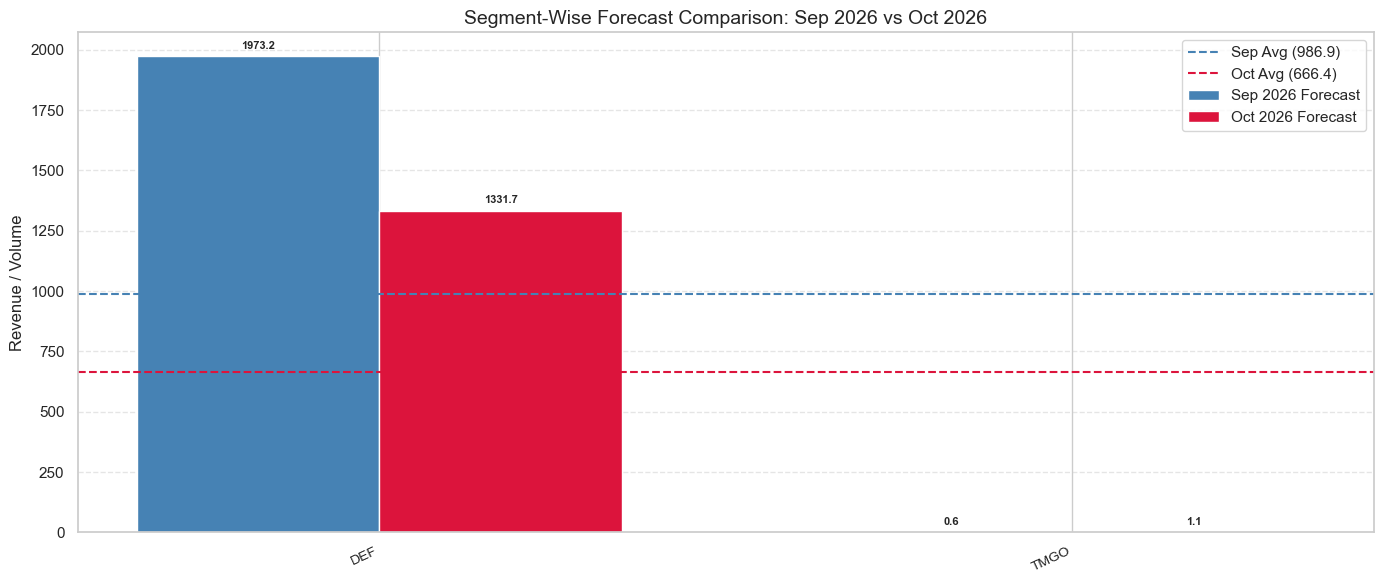

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

# 1. Define Segment Columns & Load Data
segment_cols_v = ['DEF', 'TMGO']

df_monthly_v = Invoice_Month_Aggregate_v.copy()
df_monthly_v['Invoice Date'] = pd.to_datetime(df_monthly_v['Invoice Date'])

if 'Invoice Date' in df_monthly_v.columns:
    df_monthly_v = df_monthly_v.set_index('Invoice Date')

# Ensure continuous monthly start frequency
df_monthly_v = df_monthly_v.asfreq('MS').fillna(0)

# 2. Exogenous Calendar Feature Generator
def get_exog_features_v(index_dates_v):
    exog_v = pd.DataFrame(index=index_dates_v)
    exog_v['Days_In_Month'] = exog_v.index.days_in_month
    exog_v['Business_Days'] = exog_v.index.map(
        lambda d: pd.date_range(start=d, end=d + pd.offsets.MonthEnd(1), freq='B').size
    )
    return exog_v

train_data_v = df_monthly_v[segment_cols_v]
hist_exog_v = get_exog_features_v(train_data_v.index)

# Forecast horizon for out-of-sample predictions
target_dates_v = pd.date_range(start='2026-09-01', periods=2, freq='MS')
target_exog_v = get_exog_features_v(target_dates_v)

# 3. Fit SARIMAX & Forecast
sep_oct_forecasts_v = {}

for col_v in segment_cols_v:
    series_v = train_data_v[col_v]  # Preserves exact date index frequency
    
    # Handle zero/empty segments or insufficient history (<24 months for seasonal estimation)
    if series_v.sum() == 0 or len(series_v) < 24:
        avg_val_v = series_v.tail(3).mean() if len(series_v) > 0 else 0.0
        sep_oct_forecasts_v[col_v] = [avg_val_v, avg_val_v]
        continue
        
    try:
        model_v = SARIMAX(
            series_v,
            exog=hist_exog_v,
            order=(1, 1, 1),                 # d=1 integrated differencing
            seasonal_order=(1, 0, 1, 12),    # Seasonal AR & MA components
            enforce_stationarity=True,
            enforce_invertibility=True
        )
        model_fit_v = model_v.fit(disp=False)
        
        preds_v = model_fit_v.get_forecast(steps=2, exog=target_exog_v).predicted_mean
        sep_oct_forecasts_v[col_v] = np.maximum(0, preds_v.values)
        
    except Exception as e_v:
        print(f"Warning: SARIMAX fit failed for segment '{col_v}'. Fallback applied. Error: {e_v}")
        avg_val_v = series_v.tail(6).mean()
        sep_oct_forecasts_v[col_v] = [avg_val_v, avg_val_v]

# 4. Format Summary Table
summary_df_v = pd.DataFrame(sep_oct_forecasts_v, index=['Sep 2026', 'Oct 2026']).T
summary_df_v['Total Revenue'] = summary_df_v.sum(axis=1)

print("=== Sep 2026 vs Oct 2026 Segment-Wise Forecast (Lakhs / Units) ===")
print(summary_df_v.round(2).to_string())

# Combined Totals Row
total_row_v = pd.DataFrame(summary_df_v.sum(axis=0)).T
total_row_v.index = ['TOTAL']
print("\n=== Combined Segment Totals ===")
print(total_row_v.round(2).to_string())

# 5. Side-by-Side Visualization
x_v = np.arange(len(segment_cols_v))
width_v = 0.35

fig_v, ax_v = plt.subplots(figsize=(14, 6))

rects1_v = ax_v.bar(x_v - width_v/2, summary_df_v['Sep 2026'], width_v, label='Sep 2026 Forecast', color='steelblue')
rects2_v = ax_v.bar(x_v + width_v/2, summary_df_v['Oct 2026'], width_v, label='Oct 2026 Forecast', color='crimson')

avg_sep_v = summary_df_v['Sep 2026'].mean()
avg_oct_v = summary_df_v['Oct 2026'].mean()

ax_v.axhline(avg_sep_v, color='steelblue', linestyle='--', linewidth=1.5, label=f'Sep Avg ({avg_sep_v:.1f})')
ax_v.axhline(avg_oct_v, color='crimson', linestyle='--', linewidth=1.5, label=f'Oct Avg ({avg_oct_v:.1f})')

def add_labels_v(rects_v):
    for rect_v in rects_v:
        height_v = rect_v.get_height()
        if height_v > 0:
            ax_v.annotate(
                f'{height_v:.1f}',
                xy=(rect_v.get_x() + rect_v.get_width() / 2, height_v),
                xytext=(0, 4),
                textcoords='offset points',
                ha='center',
                va='bottom',
                fontsize=8,
                fontweight='bold'
            )

add_labels_v(rects1_v)
add_labels_v(rects2_v)

ax_v.set_title('Segment-Wise Forecast Comparison: Sep 2026 vs Oct 2026', fontsize=14)
ax_v.set_ylabel('Revenue / Volume', fontsize=12)
ax_v.set_xticks(x_v)
ax_v.set_xticklabels(segment_cols_v, rotation=25, ha='right', fontsize=10)
ax_v.legend(loc='upper right')
ax_v.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


            FY26-27 FORECAST TABLE: DEF               


,Month,Actual,Predicted,Variance (Pred - Act)
0,Apr 2026,0.0,2241.57,2241.57
1,May 2026,0.0,2040.94,2040.94
2,Jun 2026,0.0,1131.75,1131.75
3,Jul 2026,2000.0,1300.78,-699.22
4,Aug 2026,NaN,1529.06,NaN
5,Sep 2026,NaN,1350.88,NaN
6,Oct 2026,NaN,1284.83,NaN
7,Nov 2026,NaN,1170.97,NaN
8,Dec 2026,NaN,2823.01,NaN
9,Jan 2027,NaN,1417.99,NaN


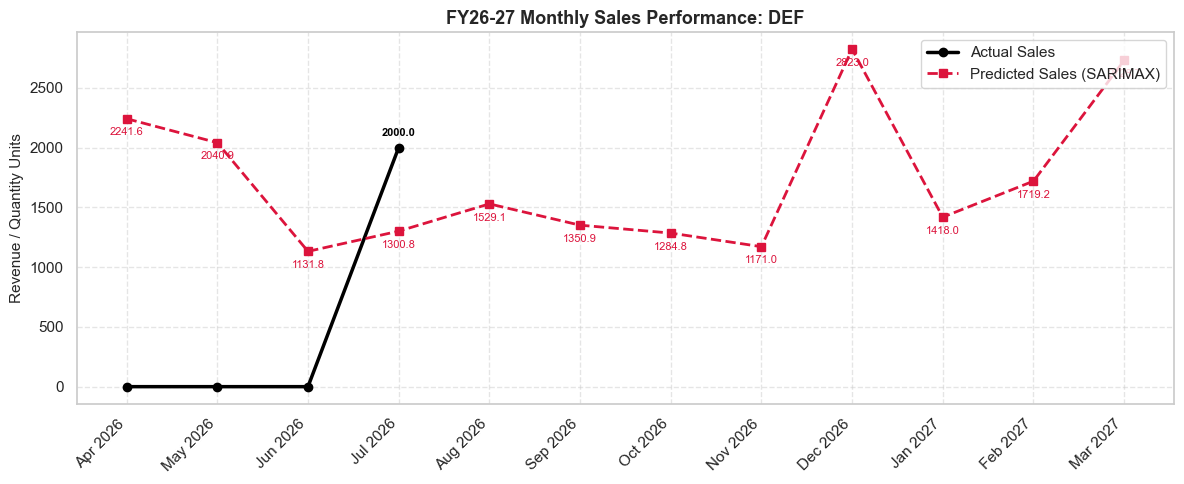


            FY26-27 FORECAST TABLE: TMGO               


,Month,Actual,Predicted,Variance (Pred - Act)
0,Apr 2026,0.0,0.02,0.02
1,May 2026,0.0,0.00,0.00
2,Jun 2026,0.0,0.00,0.00
3,Jul 2026,0.0,0.08,0.08
4,Aug 2026,NaN,0.54,NaN
5,Sep 2026,NaN,0.27,NaN
6,Oct 2026,NaN,0.42,NaN
7,Nov 2026,NaN,0.50,NaN
8,Dec 2026,NaN,0.28,NaN
9,Jan 2027,NaN,0.63,NaN


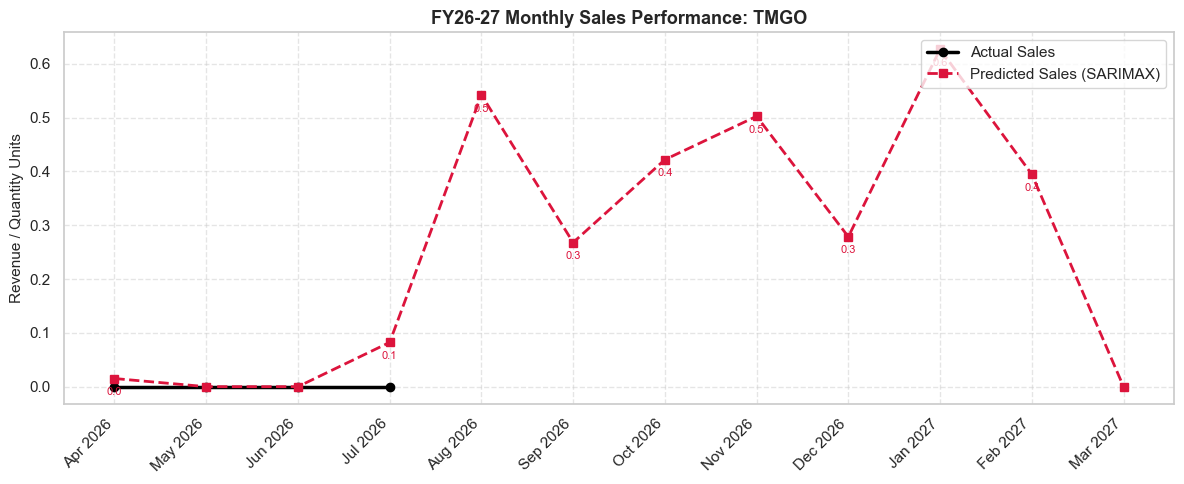

In [43]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

# 1. Load Data & Prepare Monthly Series
segment_cols_v = [
    "DEF",
    "TMGO"
]

df_monthly_v = Invoice_Month_Aggregate_v.copy()
df_monthly_v["Invoice Date"] = pd.to_datetime(df_monthly_v["Invoice Date"])

if "Invoice Date" in df_monthly_v.columns:
    df_monthly_v = df_monthly_v.set_index("Invoice Date")

# Ensure continuous monthly start frequency across full historical timeline
df_monthly_v = df_monthly_v.asfreq("MS").fillna(0)


# 2. Exogenous Calendar Feature Generator
def get_exog_features_v(index_dates_v):
    exog_v = pd.DataFrame(index=index_dates_v)
    exog_v["Days_In_Month"] = exog_v.index.days_in_month
    exog_v["Business_Days"] = exog_v.index.map(
        lambda d: pd.date_range(
            start=d, end=d + pd.offsets.MonthEnd(1), freq="B"
        ).size
    )
    return exog_v


# Full Historical Training Set
train_data_v = df_monthly_v[segment_cols_v]
hist_exog_v = get_exog_features_v(train_data_v.index)

# Display Target Horizon: FY26-27 (April 2026 to March 2027)
fy2627_dates = pd.date_range(start="2026-04-01", end="2027-03-01", freq="MS")
fy2627_exog_v = get_exog_features_v(fy2627_dates)

# DataFrames to hold FY26-27 Actuals and SARIMAX Predictions
actual_fy2627 = pd.DataFrame(index=fy2627_dates)
forecast_fy2627 = pd.DataFrame(index=fy2627_dates)

# Populate available actuals for FY26-27 target dates
for col_v in segment_cols_v:
    actual_fy2627[col_v] = train_data_v[col_v].reindex(fy2627_dates)


# 3. Fit Model on Full Past History & Forecast Target Horizon
for col_v in segment_cols_v:
    series_v = train_data_v[col_v]

    # Handle inactive or insufficient history segments (<24 months)
    if series_v.sum() == 0 or len(series_v) < 24:
        avg_val_v = series_v.tail(3).mean() if len(series_v) > 0 else 0.0
        forecast_fy2627[col_v] = avg_val_v
        continue

    try:
        # Fit SARIMAX model using ALL available historical data
        model_v = SARIMAX(
            series_v,
            exog=hist_exog_v,
            order=(2, 0, 1),
            seasonal_order=(1, 0, 1, 12),
            enforce_stationarity=True,
            enforce_invertibility=True,
        )
        model_fit_v = model_v.fit(disp=False)

        # Separate FY26-27 horizon into historical months (In-Sample) and future months (Out-of-Sample)
        max_hist_date = series_v.index.max()
        in_sample_dates = fy2627_dates[fy2627_dates <= max_hist_date]
        out_sample_dates = fy2627_dates[fy2627_dates > max_hist_date]

        col_preds = pd.Series(index=fy2627_dates, dtype=float)

        # In-sample fitted values for historical months of FY26-27
        if len(in_sample_dates) > 0:
            in_pred = model_fit_v.predict(
                start=in_sample_dates[0],
                end=in_sample_dates[-1],
                exog=hist_exog_v.loc[in_sample_dates],
            )
            col_preds.loc[in_sample_dates] = in_pred

        # Out-of-sample forecast for remaining months of FY26-27
        if len(out_sample_dates) > 0:
            out_pred = model_fit_v.get_forecast(
                steps=len(out_sample_dates),
                exog=fy2627_exog_v.loc[out_sample_dates],
            ).predicted_mean
            col_preds.loc[out_sample_dates] = out_pred

        # Clip predictions to 0 to prevent negative demand
        forecast_fy2627[col_v] = np.maximum(0, col_preds)

    except Exception as e_v:
        print(
            f"Warning: SARIMAX fit failed for segment '{col_v}'. Fallback applied. Error: {e_v}"
        )
        avg_val_v = series_v.tail(6).mean()
        forecast_fy2627[col_v] = avg_val_v


# Format Month Axis Labels (Apr 2026 ... Mar 2027)
date_labels_v = fy2627_dates.strftime("%b %Y")


# 4. Display Segment Tables & Line Charts (Apr 2026 - Mar 2027)
for col_v in segment_cols_v:
    # Build Display Dataframe
    segment_table = pd.DataFrame(
        {
            "Month": date_labels_v,
            "Actual": actual_fy2627[col_v].values,
            "Predicted": forecast_fy2627[col_v].values,
        }
    )

    segment_table["Variance (Pred - Act)"] = (
        segment_table["Predicted"] - segment_table["Actual"]
    )

    print(f"\n==========================================================")
    print(f"            FY26-27 FORECAST TABLE: {col_v}               ")
    print(f"==========================================================")
    display(segment_table.round(2))
    segment_table.round(2).to_excel(f"{col_v}_Volume_Forecast_Data.xlsx")

    # Plot Line Chart (Apr-26 to Mar-27)
    fig_v, ax_v = plt.subplots(figsize=(12, 5))

    # Actual Sales Line
    ax_v.plot(
        date_labels_v,
        segment_table["Actual"],
        marker="o",
        linewidth=2.5,
        color="black",
        label="Actual Sales",
    )

    # Predicted Sales Line
    ax_v.plot(
        date_labels_v,
        segment_table["Predicted"],
        marker="s",
        linestyle="--",
        linewidth=2,
        color="crimson",
        label="Predicted Sales (SARIMAX)",
    )

    # Point Annotations
    for i_v, (act_v, pred_v) in enumerate(
        zip(segment_table["Actual"], segment_table["Predicted"])
    ):
        if not np.isnan(act_v) and act_v > 0:
            ax_v.annotate(
                f"{act_v:.1f}",
                (i_v, act_v),
                xytext=(0, 8),
                textcoords="offset points",
                ha="center",
                fontsize=8,
                color="black",
                fontweight="bold",
            )
        if not np.isnan(pred_v) and pred_v > 0:
            ax_v.annotate(
                f"{pred_v:.1f}",
                (i_v, pred_v),
                xytext=(0, -12),
                textcoords="offset points",
                ha="center",
                fontsize=8,
                color="crimson",
            )

    ax_v.set_title(
        f"FY26-27 Monthly Sales Performance: {col_v}",
        fontsize=13,
        fontweight="bold",
    )
    ax_v.set_ylabel("Revenue / Quantity Units", fontsize=11)
    ax_v.grid(True, linestyle="--", alpha=0.5)
    ax_v.legend(loc="upper right")
    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

                  OVERALL MODEL EFFICIENCY SUMMARY                   


,Segment,Evaluated Months,MAE (Units),RMSE (Units),MAPE (%),Accuracy (%)
0,DEF,1,699.22,699.22,34.96,65.04



----------------------------------------------------------
         MODEL ACCURACY BREAKDOWN: DEF                 
----------------------------------------------------------


,Month,Actual,Predicted,Abs Error,APE (%),Monthly Accuracy (%)
0,Apr 2026,0.0,2241.57,2241.57,0.00,100.00
1,May 2026,0.0,2040.94,2040.94,0.00,100.00
2,Jun 2026,0.0,1131.75,1131.75,0.00,100.00
3,Jul 2026,2000.0,1300.78,699.22,34.96,65.04



----------------------------------------------------------
         MODEL ACCURACY BREAKDOWN: TMGO                 
----------------------------------------------------------


,Month,Actual,Predicted,Abs Error,APE (%),Monthly Accuracy (%)
0,Apr 2026,0.0,0.02,0.02,0.0,100.0
1,May 2026,0.0,0.00,0.00,0.0,100.0
2,Jun 2026,0.0,0.00,0.00,0.0,100.0
3,Jul 2026,0.0,0.08,0.08,0.0,100.0


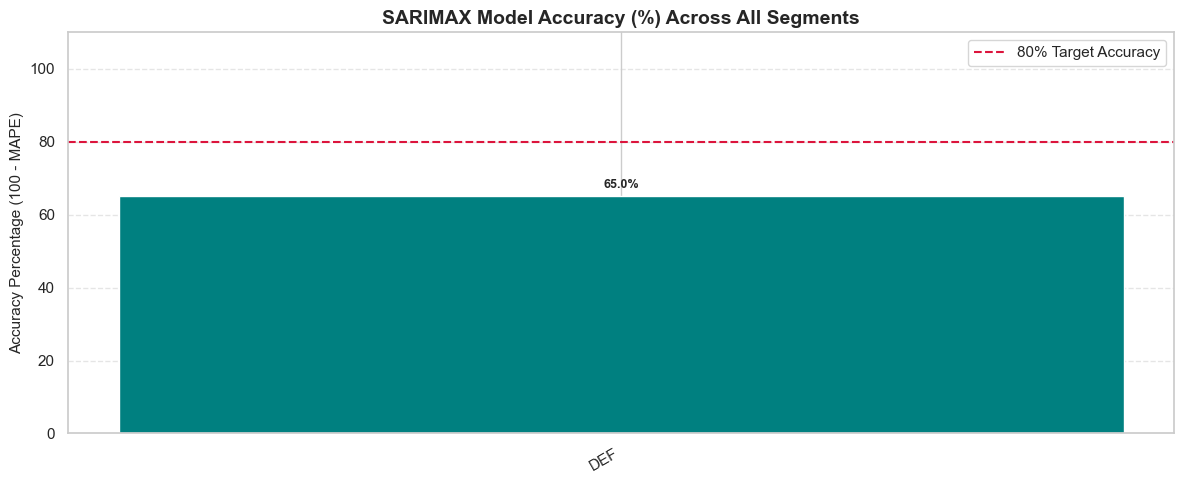

In [44]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

# ---------------------------------------------------------
# 1. Compute Monthly Accuracy Metrics (Historical Period Only)
# ---------------------------------------------------------
metrics_list = []

for col_v in segment_cols_v:
    # Filter for months where Actual data is present and non-null
    valid_mask = actual_fy2627[col_v].notna() & (actual_fy2627[col_v] > 0)

    y_actual = actual_fy2627.loc[valid_mask, col_v]
    y_pred = forecast_fy2627.loc[valid_mask, col_v]

    if len(y_actual) > 0:
        # Calculate Error Metrics
        mae = mean_absolute_error(y_actual, y_pred)
        rmse = np.sqrt(mean_squared_error(y_actual, y_pred))

        # Absolute Percentage Error per month
        ape = np.abs((y_actual - y_pred) / y_actual)
        mape = np.mean(ape) * 100

        # Model Efficiency / Accuracy %
        accuracy = max(0, 100 - mape)

        metrics_list.append(
            {
                "Segment": col_v,
                "Evaluated Months": len(y_actual),
                "MAE (Units)": round(mae, 2),
                "RMSE (Units)": round(rmse, 2),
                "MAPE (%)": round(mape, 2),
                "Accuracy (%)": round(accuracy, 2),
            }
        )

# Create Master Summary DataFrame
efficiency_df = pd.DataFrame(metrics_list).sort_values(
    by="Accuracy (%)", ascending=False
)

# ---------------------------------------------------------
# 2. Print Master Efficiency Summary
# ---------------------------------------------------------
print("=====================================================================")
print("                  OVERALL MODEL EFFICIENCY SUMMARY                   ")
print("=====================================================================")
display(efficiency_df.reset_index(drop=True))

# ---------------------------------------------------------
# 3. Print Month-by-Month Detailed Accuracy Breakdown per Segment
# ---------------------------------------------------------
for col_v in segment_cols_v:
    valid_mask = actual_fy2627[col_v].notna()

    eval_df = pd.DataFrame(
        {
            "Month": date_labels_v[valid_mask],
            "Actual": actual_fy2627.loc[valid_mask, col_v].values,
            "Predicted": forecast_fy2627.loc[valid_mask, col_v].values,
        }
    )

    # Compute Error & Accuracy columns
    eval_df["Abs Error"] = np.abs(eval_df["Predicted"] - eval_df["Actual"])
    eval_df["APE (%)"] = np.where(
        eval_df["Actual"] > 0,
        (eval_df["Abs Error"] / eval_df["Actual"]) * 100,
        0,
    )
    eval_df["Monthly Accuracy (%)"] = np.maximum(0, 100 - eval_df["APE (%)"])

    print(f"\n----------------------------------------------------------")
    print(f"         MODEL ACCURACY BREAKDOWN: {col_v}                 ")
    print(f"----------------------------------------------------------")
    display(eval_df.round(2))

# ---------------------------------------------------------
# 4. Model Efficiency Comparison Visualization
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(
    efficiency_df["Segment"],
    efficiency_df["Accuracy (%)"],
    color="teal",
    width=0.5,
)

# Add threshold line for good accuracy (80%)
ax.axhline(
    80, color="crimson", linestyle="--", linewidth=1.5, label="80% Target Accuracy"
)

# Annotate accuracy values on top of bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f"{height:.1f}%",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 4),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )

ax.set_title(
    "SARIMAX Model Accuracy (%) Across All Segments",
    fontsize=14,
    fontweight="bold",
)
ax.set_ylabel("Accuracy Percentage (100 - MAPE)", fontsize=11)
ax.set_ylim(0, 110)
ax.set_xticks(range(len(efficiency_df["Segment"])))
ax.set_xticklabels(efficiency_df["Segment"], rotation=30, ha="right")
ax.legend(loc="upper right")
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()